<a href="https://colab.research.google.com/github/e23281-lgtm/Statistical-Learning-e23281/blob/main/Copy_of_fundamentals_of_probability_assignment_answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


## Sample Answer

Let the disk be

$$\Omega=\{(x,y)\in \mathbb{R}^2 : x^2+y^2\le 10^2\}.$$


Let $A$ be the event that the chosen point lies within $1$ unit of the boundary. Since the boundary is the circle of radius $10$, this means the point has distance at least $9$ from the center and at most $10$. Thus

$$A=\left\{(x,y)\in \Omega : 9\le \sqrt{x^2+y^2}\le 10\right\}.$$

So $A$ is the outer annulus of the disk.

We now model the phrase “chosen at random” in two different ways.

---

**Uniform distribution with respect to area**

In this model, equal areas are assigned equal probabilities. Thus the probability of an event is its area divided by the total area of the disk.

The total area of the disk is

$$
\pi(10)^2=100\pi.
$$

The event $A$ is the annulus between radii $9$ and $10$, so its area is

$$
\pi(10)^2-\pi(9)^2
=100\pi-81\pi
=19\pi.
$$

Therefore,

$$
P(A)=\frac{\text{area of }A}{\text{area of disk}}
=\frac{19\pi}{100\pi}
=\frac{19}{100}.
$$

Hence, under the area-uniform model,

$$
\boxed{P(A)=\frac{19}{100}}.
$$

---

**Uniform distribution of the radius**


In this model, we have two independent variables:
1.  Radius ($r$): Chosen uniformly from the interval $[0, 10]$.
2.  Angle ($\theta$): Chosen uniformly from the interval $[0, 2\pi)$.

Since the choice of angle is independent of the radius, the direction does not affect the probability of falling within a certain distance from the center. Therefore, we can focus entirely on the radius.

1. *Total Sample Space for the Radius:*
The total possible distance from the center is the interval $[0, 10]$, which has a total "length" of:
$$\text{Total Length} = 10 - 0 = 10$$

2. *Favorable Outcomes for Event $A$:*
The event $A$ (the point being within 1 unit of the boundary) occurs when the distance $r$ is between $9$ and $10$. This successful interval has a "length" of:
$$\text{Favorable Length} = 10 - 9 = 1$$

3. *Probability Calculation:*
Since the radius is chosen uniformly, the probability of the event is the ratio of the favorable length to the total length:
$$P(A) = \frac{\text{Favorable Length}}{\text{Total Length}}$$

$$
\boxed{P(A)=\frac{1}{10}}.
$$



---

**Why the two answers differ**

The two answers differ because the phrase “a point is chosen at random from a disk” does not determine a unique probability model.

In the first model, probability is distributed uniformly over **area**. Since the outer part of the disk occupies a relatively large amount of area, points near the boundary are more likely than points near the center. This gives


$$P(A)=\frac{19}{100}.$$

In the second model, probability is distributed uniformly over the **radius**. That means each radial interval of the same length is equally likely, regardless of how much area it contains. Since the interval $[9,10]$ has length $1$ out of a total radial length $10$, this gives

$$P(A)=\frac{1}{10}.$$

So the difference comes from using two different probability measures on the same geometric set. The event $A$ is the same in both cases, but the meaning of “chosen at random” is different.


---

> This example shows that probabilities are not determined by the set of possible outcomes alone; they also depend on the probability measure. The same event may therefore have different probabilities under different mathematical models of the phrase “chosen at random.”

---

**Probability of Throwing Darts**

If you repeatedly throw darts at a circular board in a way that has no directional or radial bias, the long-run frequency of landing in a region is expected to be approximately proportional to that region's **area**. In that case, the empirical probability of landing within $1$ unit of the boundary would be close to

$$
\frac{19}{100}.
$$

The **radius-uniform model** would correspond to a very different physical procedure: first choose a distance $r$ uniformly from $[0,10]$, then choose a direction, and place the point there. That is not what ordinary random scattering produces.

So from a practical point of view:

* **empirical dart-throwing type results** $\to$ area-uniform,
* **artificial two-step sampling rule** $\to$ radius-uniform.


> In most physical experiments, “randomly chosen point in a disk” is modeled by the uniform distribution on area; the radius-uniform model represents a different sampling mechanism, not ordinary geometric randomness.


In [ ]:
import numpy as np

# Part 1 Simulation (Area Uniform)
n_samples = 100000
# Generating points in a square and filtering for the disk
x = np.random.uniform(-10, 10, n_samples)
y = np.random.uniform(-10, 10, n_samples)
r_squared = x**2 + y**2

# Filter only points inside the disk (r <= 10)
inside_disk = r_squared <= 100
r_in_disk = np.sqrt(r_squared[inside_disk])

p_a_area = np.mean(r_in_disk >= 9)
print(f"P(A) Area-based: {p_a_area:.3f}")

# Part 2 Simulation (Distance Uniform)
r_uniform = np.random.uniform(0, 10, n_samples)
p_a_dist = np.mean(r_uniform >= 9)
print(f"P(A) Distance-based: {p_a_dist:.3f}")

P(A) Area-based: 0.189
P(A) Distance-based: 0.100


The answers differ because the definition of "at random" changes the probability density. In Model 1, every equal area on the disk has an equal chance of being hit. Since the "outer rings" of a circle have more area than the "inner circles," a point is more likely to land near the edge.
      Therefore;
             this gives
                    P(A) = 0.189
 In Model 2, we assume every radial distance is equally likely, which ignores the fact that the outer edge occupies more physical space than the center.
     Therefore;
             this gives
                    P(A) = 0.1


# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

## Sample Answer

**Preliminary geometric fact**

Let the circle be

$$
x^2+y^2=1.
$$

The side length of the inscribed equilateral triangle is

$$
\sqrt{3}.
$$

A chord is longer than $\sqrt{3}$ if and only if its perpendicular distance from the center is less than $1/2$.


**Proof:**

If a chord is at distance $r\in[0,1]$ from the center, then half its length is the horizontal leg of a right triangle with hypotenuse $1$ and other leg $r$. Hence the chord length is

$$
L(r)=2\sqrt{1-r^2}.
$$

We want

$$
L(r)>\sqrt{3}.
$$

This is equivalent to

$$
r<\frac12.
$$

So the event of interest is precisely

$$
A=\{ \text{distance of chord from center} < 1/2\}.
$$



### Model-1: Random endpoint, then random angle from that endpoint


This model is often described more simply as:

* choose one endpoint uniformly on the circumference,
* then choose the other endpoint uniformly on the circumference.

By rotational symmetry, we may fix the first endpoint and choose the second uniformly.

---

**Probability space**

Let

$$
\Omega_1=[0,\pi]
$$

with Borel sigma-algebra

$$
\mathfrak A_1=\mathfrak B([0,\pi]),
$$

and probability measure

$$
P_1(E)=\frac{\lambda(E)}{\pi},
\qquad E\in\mathfrak A_1,
$$

where $\lambda$ is Lebesgue measure.

Interpret $\theta\in[0,\pi]$ as the smaller central angle subtended by the chord.

---

**Event**

A chord subtending angle $\theta$ has length

$$
L(\theta)=2\sin(\theta/2).
$$

We want

$$
L(\theta)>\sqrt{3}.
$$

Thus

$$
2\sin(\theta/2)>\sqrt{3}
$$

$$
\sin(\theta/2)>\frac{\sqrt{3}}{2}.
$$

Since $\theta/2\in[0,\pi/2]$, this is equivalent to

$$
\theta/2>\pi/3
\quad\Longleftrightarrow\quad
\theta>2\pi/3.
$$

So

$$
A_1=(2\pi/3,\pi].
$$

---

**Probability**

Therefore

$$
P_1(A_1)=\frac{\pi-2\pi/3}{\pi}=\frac{1}{3}.
$$

So under Model-1,

$$
\boxed{P_1(A_1)=\frac13}.
$$



### Model-2: Random radius, then choose the chord perpendicular to it at a random point

This model is:

* choose a radius,
* choose a point uniformly along that radius,
* draw the chord perpendicular to the radius through that point.

Equivalently, the distance of the chord from the center is chosen uniformly in $[0,1]$.

---

**Probability space**

Let

$$
\Omega_2=[0,1]
$$

with sigma-algebra

$$
\mathfrak A_2=\mathfrak B([0,1]),
$$

and probability measure

$$
P_2(E)=\lambda(E),
\qquad E\in\mathfrak A_2,
$$

since $\lambda([0,1])=1$.

Interpret $r\in[0,1]$ as the perpendicular distance from the center to the chord.

---

**Event**

From the preliminary calculation, the chord is longer than the side of the inscribed equilateral triangle exactly when

$$
r<1/2.
$$

So

$$
A_2=[0,1/2).
$$

---

**Probability**

Hence

$$
P_2(A_2)=\lambda([0,1/2))=\frac12.
$$

So under Model 2,

$$
\boxed{P_2(A_2)=\frac12}.
$$

###

### Model-3: Random midpoint uniformly in the disk

This model is:

* choose the midpoint of the chord uniformly from the whole disk,
* draw the unique chord having that midpoint.

Since every chord is uniquely determined by its midpoint, this defines a probability law on chords.

---

**Probability space**

Let

$$
\Omega_3=\{(x,y)\in\mathbb R^2:x^2+y^2\le 1\}
$$

be the closed unit disk, with sigma-algebra

$$
\mathfrak A_3=\mathfrak B(\Omega_3).
$$

Define $P_3$ by normalized area:

$$
P_3(E)=\frac{\lambda_2(E)}{\pi},
\qquad E\in\mathfrak A_3,
$$

where $\lambda_2$ is planar Lebesgue measure.

Interpret $(x,y)$ as the midpoint of the chord.

---

**Event**

If the midpoint is $(x,y)$, then its distance from the center is

$$
r=\sqrt{x^2+y^2}.
$$

As shown above, the chord is longer than $\sqrt{3}$ exactly when

$$
r<1/2.
$$

Thus

$$
A_3=\{(x,y)\in\Omega_3:x^2+y^2<1/4\}.
$$

This is the disk of radius (1/2).

---

**Probability**

Therefore

$$
P_3(A_3)=\frac{\text{area of disk of radius }1/2}{\text{area of unit disk}}
=\frac{\pi(1/2)^2}{\pi}
=\frac14.
$$

So under Model 3,

$$
\boxed{P_3(A_3)=\frac14}.
$$


### Conclusion

We have obtained three different answers:

| Model | Parameter chosen uniformly       | Probability     |
| ----- | -------------------------------- | --------------- |
| 1     | endpoint angle / subtended angle | $\frac{1}{3}$ |
| 2     | distance from center             | $\frac{1}{2}$ |
| 3     | midpoint in the disk             | $\frac{1}{4}$ |

Each answer is correct for a different mathematically precise meaning of “choose a chord at random.”

This is Bertrand's paradox: the verbal description alone does not determine a unique probability model. One must specify the sampling procedure, or equivalently the probability space.

---


Let the circle have radius $1$. A chord exceeds the side length of the inscribed equilateral triangle if and only if its distance from the center is less than $1/2$.

Three natural models of “random chord” are:

1. **Uniform endpoint model:** choose one endpoint uniformly, then the other uniformly. This gives a uniform central angle $\theta\in[0,\pi]$. The chord is long exactly when $\theta>2\pi/3$, hence the probability is
   $$
   \frac{\pi-2\pi/3}{\pi}=\frac13.
   $$

2. **Uniform distance model:** choose the perpendicular distance $r$ from the center uniformly in $[0,1]$. The chord is long exactly when $r<1/2$, hence the probability is
   $$
   \frac12.
   $$

3. **Uniform midpoint model:** choose the midpoint uniformly in the unit disk. The chord is long exactly when the midpoint lies in the disk of radius $1/2$, hence the probability is
   $$
   \frac{\pi(1/2)^2}{\pi}=\frac14.
   $$

Thus the phrase “a chord is chosen at random” is ambiguous: different natural probability spaces yield different answers.


In [ ]:
import numpy as np

n_samples = 1000000
R = 1
triangle_side = np.sqrt(3) * R

# --- Model 1: Endpoint Angle ---
theta1 = np.random.uniform(0, 2*np.pi, n_samples)
theta2 = np.random.uniform(0, 2*np.pi, n_samples)
chord_lengths_1 = 2 * R * np.abs(np.sin((theta1 - theta2) / 2))
prob_1 = np.mean(chord_lengths_1 > triangle_side)

# --- Model 2: Distance from Center ---
d = np.random.uniform(0, R, n_samples)
chord_lengths_2 = 2 * np.sqrt(R**2 - d**2)
prob_2 = np.mean(chord_lengths_2 > triangle_side)

# --- Model 3: Midpoint in the Disk ---
# To pick a point uniformly by area, we use: r = R * sqrt(U)
u = np.random.uniform(0, 1, n_samples)
r_midpoints = R * np.sqrt(u)
# A chord exceeds the triangle side if its midpoint is within R/2 of the center
prob_3 = np.mean(r_midpoints < R/2)

print(f"Model 1 (Endpoint Angle) Probability: {prob_1:.4f} (Target: 1/3)")
print(f"Model 2 (Distance from Center) Probability: {prob_2:.4f} (Target: 1/2)")
print(f"Model 3 (Midpoint in the Disk) Probability: {prob_3:.4f} (Target: 1/4)")

Model 1 (Endpoint Angle) Probability: 0.3335 (Target: 1/3)
Model 2 (Distance from Center) Probability: 0.4999 (Target: 1/2)
Model 3 (Midpoint in the Disk) Probability: 0.2495 (Target: 1/4)


Bertrand's Paradox demonstrates that the probability of a "random chord" depends on how the randomness is modeled. We compare the chord length to the side of an inscribed equilateral triangle ($L = \sqrt{3}R$).The Three Models:Model 1 (Endpoint Angle): Two points are chosen uniformly on the circumference.Model 2 (Distance from Center): A radius is chosen, and a point on it is chosen uniformly to be the midpoint.Model 3 (Midpoint in the Disk): A point is chosen uniformly anywhere within the disk's area to be the midpoint.

Conclusion:
Model 1 ($P=1/3$): Assumes uniformity over the angles of the endpoints.Model 2 ($P=1/2$): Assumes uniformity over the radial distance of the chord from the center.Model 3 ($P=1/4$): Assumes the midpoint of the chord is uniformly distributed over the area of the disk. For the chord to be longer than the triangle side, the midpoint must fall within a smaller concentric circle of radius $R/2$. Since Area $\propto r^2$, the probability is $(1/2)^2 = 1/4$.

#Q3) Transformer Failiures

In a certain electricity distribution district, the number of emergency transformer failures reported in a single day is modeled as a discrete random variable $X$. Assume that $X$ takes values in the set $\{0,1,2,3\}$, with probabilities

$$
P(X=0)=0.50,\qquad P(X=1)=0.30,\qquad P(X=2)=0.15,\qquad P(X=3)=0.05.
$$

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.
2. Define $X$ as a random variable on this space.
3. Determine the probability mass function of $X$.
4. Compute the expectation $E[X]$.
5. Compute the variance $\mathrm{Var}(X)$.
6. Find $P(X\ge 1)$ and $P(X\ge 2)$.
7. Briefly explain the practical meaning of the expectation and variance in this setting.



## Sample Answer

Here is a concise solution.

1. A suitable probability space is

$$
\Omega=\{0,1,2,3\}, \qquad \mathfrak F=\mathfrak P(\Omega),
$$

where $\mathfrak P(\Omega)$ is the power set of $\Omega$. Define $P$ on singletons by

$$
P(\{0\})=0.50,\qquad P(\{1\})=0.30,\qquad P(\{2\})=0.15,\qquad P(\{3\})=0.05,
$$

and for any event $A\subseteq \Omega$,

$$
P(A)=\sum_{\omega\in A} P({\omega}).
$$

2. Define the random variable $X:\Omega\to \mathbb R$ by

$$
X(\omega)=\omega, \qquad \omega\in \Omega.
$$

3. The probability mass function is

$$
p_X(x)=P(X=x)=
\begin{cases}
0.50, & x=0,\\
0.30, & x=1,\\
0.15, & x=2,\\
0.05, & x=3,\\
0, & \text{otherwise}.
\end{cases}
$$

4. The expectation is

$$
E[X]=\sum_x x\,p_X(x)
=0(0.50)+1(0.30)+2(0.15)+3(0.05)=0.75.
$$

5. First compute

$$
E[X^2]=0^2(0.50)+1^2(0.30)+2^2(0.15)+3^2(0.05)=1.35.
$$

Hence

$$
\mathrm{Var}(X)=E[X^2]-(E[X])^2=1.35-(0.75)^2=0.7875.
$$

6. The required probabilities are

$$
P(X\ge 1)=P(X=1)+P(X=2)+P(X=3)=0.30+0.15+0.05=0.50,
$$

and

$$
P(X\ge 2)=P(X=2)+P(X=3)=0.15+0.05=0.20.
$$

7. The expectation $E[X]=0.75$ means that the average number of emergency transformer failures per day is $0.75$. The variance $\mathrm{Var}(X)=0.7875$ measures the day-to-day variability in the number of failures, so it indicates how much actual daily counts may fluctuate around the average.


4. Expectation E[X]: 0.75
5. Variance Var(X): 0.7875
6. P(X >= 1): 0.50
6. P(X >= 2): 0.20


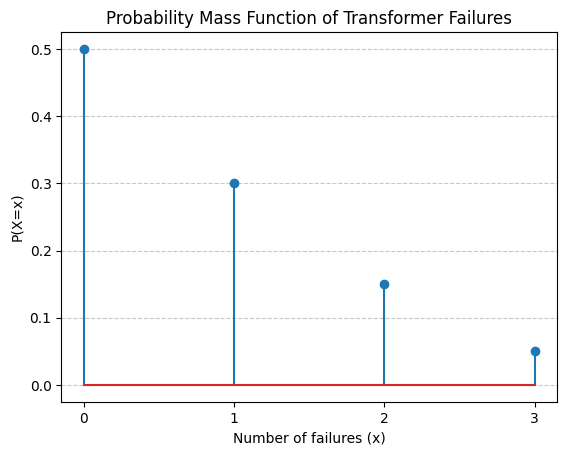

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.array([0, 1, 2, 3])
p = np.array([0.50, 0.30, 0.15, 0.05])

# 4. Expectation E[X] = sum(x * p)
expectation = np.sum(x * p)

# 5. Variance Var(X) = E[X^2] - (E[X])^2
expectation_x2 = np.sum((x**2) * p)
variance = expectation_x2 - (expectation**2)

# 6. Calculations
p_ge_1 = np.sum(p[x >= 1]) # P(X >= 1)
p_ge_2 = np.sum(p[x >= 2]) # P(X >= 2)

print(f"4. Expectation E[X]: {expectation:.2f}")
print(f"5. Variance Var(X): {variance:.4f}")
print(f"6. P(X >= 1): {p_ge_1:.2f}")
print(f"6. P(X >= 2): {p_ge_2:.2f}")

# Visualizing the PMF
plt.stem(x, p)
plt.xlabel('Number of failures (x)')
plt.ylabel('P(X=x)')
plt.title('Probability Mass Function of Transformer Failures')
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

1.Probability Space $(\Omega, \mathcal{F}, P)$

Sample Space ($\Omega$): The set of possible failure counts. $\Omega = \{0, 1, 2, 3\}$.

Sigma-algebra ($\mathcal{F}$): The power set $\mathcal{P}(\Omega)$, containing all $2^4 = 16$ possible events.

Probability Measure ($P$): Defined as;$P(\{0\}) = 0.50, P(\{1\}) = 0.30, P(\{2\}) = 0.15, P(\{3\}) = 0.05$.

2.Random Variable $X$$X$ is the identity mapping $X: \Omega \to \mathbb{R}$ such that $X(\omega) = \omega$.

3.Probability Mass Function (PMF)The PMF is $p_X(x) = P(X=x)$, which is exactly the probabilities given above.

 Practical Meaning

 Expectation ($E[X]$): Represents the long-term average number of failures per day. If we monitored this district for many years, we would expect an average of 0.75 failures daily.

 Variance ($Var(X)$): Measures the "spread" or uncertainty of the failures. A higher variance would mean the number of failures fluctuates wildly from day to day, while a lower variance means the daily failure count is more consistent.

# Q4) Probability of Defective Items

In a manufacturing process, the proportion of defective items in a large batch produced on a given day is modeled by a continuous random variable $X$. Since $X$ represents a proportion, it takes values in the interval $[0,1]$. Suppose that $X$ has a Beta distribution with parameters $\alpha=2$ and $\beta=18$, so that its density is

$$
f(x)=
\begin{cases}
\dfrac{1}{B(2,18)}x^{1}(1-x)^{17}, & 0<x<1,\\\
0, & \text{otherwise},
\end{cases}
$$

where $B(2,18)$ is the Beta function.

Answer the following:

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.

2. Define $X$ as a continuous random variable on this space.

3. Write down the probability density function of $X$.

4. Verify that $f$ is a valid probability density function.

5. Compute the expectation $E[X]$.

6. Compute the variance $\mathrm{Var}(X)$.

7. Find the probability that the defective proportion is at most $0.10$, that is, compute

$$
P(X\le 0.10).
$$

You may leave your answer in Beta integral form.

8. Find the probability that the defective proportion lies between $0.05$ and $0.15$, that is, compute

$$
P(0.05\le X\le 0.15).
$$

You may leave your answer in integral form.

9. Briefly explain why a Beta distribution is a reasonable model for this situation.

10. Interpret the expectation and variance in the context of production quality.


## Sample Answer

Here is a sample answer.

1. A suitable probability space is

$$
\Omega=[0,1], \qquad \mathfrak F=\mathfrak B([0,1]),
$$

where $\mathfrak B([0,1])$ is the Borel $\sigma$-algebra on $[0,1]$. Define the probability measure $P$ by

$$
P(A)=\int_A f(x)\,dx, \qquad A\in \mathfrak F,
$$

where

$$
f(x)=
\begin{cases}
\dfrac{1}{B(2,18)}x(1-x)^{17}, & 0<x<1,\
0, & \text{otherwise}.
\end{cases}
$$

2. Define the random variable $X:\Omega\to\mathbb R$ by

$$
X(\omega)=\omega, \qquad \omega\in[0,1].
$$

Thus $X$ records the defective proportion in the batch.

3. The probability density function of $X$ is

$$
f_X(x)=
\begin{cases}
\dfrac{1}{B(2,18)}x(1-x)^{17}, & 0<x<1,\\
0, & \text{otherwise}.
\end{cases}
$$

4. To verify that $f$ is a valid density, note first that $f(x)\ge 0$ for all $x$. Also,

$$
\int_{-\infty}^{\infty} f(x)\,dx
=\int_0^1 \dfrac{1}{B(2,18)}x(1-x)^{17}\,dx
=\dfrac{1}{B(2,18)}B(2,18)
=1.
$$

So $f$ is a valid probability density function.

5. Since $X\sim \mathrm{Beta}(2,18)$,

$$
E[X]=\frac{\alpha}{\alpha+\beta}=\frac{2}{20}=0.10.
$$

6. The variance of a Beta$(\alpha,\beta)$ random variable is

$$
\mathrm{Var}(X)=\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}.
$$

Hence

$$
\mathrm{Var}(X)=\frac{2\cdot 18}{20^2\cdot 21}
=\frac{36}{8400}
=\frac{3}{700}
\approx 0.00429.
$$

7. The probability that the defective proportion is at most $0.10$ is

$$
P(X\le 0.10)=\int_0^{0.10} \dfrac{1}{B(2,18)}x(1-x)^{17},dx.
$$

Equivalently,

$$
P(X\le 0.10)=I_{0.10}(2,18),
$$

where $I_x(\alpha,\beta)$ denotes the regularized incomplete Beta function.

8. The probability that the defective proportion lies between $0.05$ and $0.15$ is

$$
P(0.05\le X\le 0.15)=\int_{0.05}^{0.15} \dfrac{1}{B(2,18)}x(1-x)^{17},dx.
$$

Equivalently,

$$
P(0.05\le X\le 0.15)=I_{0.15}(2,18)-I_{0.05}(2,18).
$$

9. A Beta distribution is reasonable here because the defective proportion is a continuous quantity constrained to lie between $0$ and $1$, and the Beta family is specifically designed to model proportions and rates.

10. The expectation

$$
E[X]=0.10
$$

means that the long-run average defective proportion is $10%$. The variance

$$
\mathrm{Var}(X)\approx 0.00429
$$

measures the variability in the defective proportion from batch to batch, so it indicates how stable or unstable the manufacturing quality is over time.


### The plot of the $\beta$-distribution

In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import beta

# Parameters
a_beta, b_beta = 2, 18

# 5. Expectation E[X] = alpha / (alpha + beta)
expectation = a_beta / (a_beta + b_beta)

# 6. Variance Var(X)
variance = (a_beta * b_beta) / ((a_beta + b_beta)**2 * (a_beta + b_beta + 1))

# 7. P(X <= 0.10)
prob_at_most_10 = beta.cdf(0.10, a_beta, b_beta)

# 8. P(0.05 <= X <= 0.15)
prob_between = beta.cdf(0.15, a_beta, b_beta) - beta.cdf(0.05, a_beta, b_beta)

print(f"5. Expectation E[X]: {expectation:.4f}")
print(f"6. Variance Var(X): {variance:.4f}")
print(f"7. P(X <= 0.10): {prob_at_most_10:.4f}")
print(f"8. P(0.05 <= X <= 0.15): {prob_between:.4f}")

# Plotting using Sir's Plotly Style
x_vals = np.linspace(0, 1, 500)
y_vals = beta.pdf(x_vals, a_beta, b_beta)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x_vals,
    y=y_vals,
    mode='lines',
    fill='tozeroy',
    name='Beta(2, 18)',
    line=dict(color='firebrick', width=2)
))

fig.update_layout(
    title='Beta Distribution of Defective Item Proportions',
    xaxis_title='Proportion (x)',
    yaxis_title='Probability Density',
    template='plotly_white'
)
fig.show()

5. Expectation E[X]: 0.1000
6. Variance Var(X): 0.0043
7. P(X <= 0.10): 0.5797
8. P(0.05 <= X <= 0.15): 0.5562


1. Probability Space $(\Omega, \mathcal{F}, P)$

    Sample Space ($\Omega$): The interval $[0, 1]$.

    Sigma-algebra ($\mathcal{F}$): The Borel $\sigma$-algebra on $[0, 1]$, denoted as $\mathcal{B}([0, 1])$.

    Probability Measure ($P$): For any event $A \in \mathcal{F}$, $P(A) = \int_A f(x) dx$.

2. Random Variable $X$$X$ is a continuous random variable defined as the identity map $X: \Omega \to [0, 1]$.

3. Probability Density Function (PDF)The PDF for $X \sim \text{Beta}(\alpha=2, \beta=18)$ is:

$$f(x) = \frac{1}{B(2, 18)} x^{2-1} (1-x)^{18-1} = \frac{1}{B(2, 18)} x^1 (1-x)^{17}, \quad 0 < x < 1$$

4. Verification of Validity
A function is a valid PDF if:

    1)$f(x) \geq 0$ for all $x$: Since $x \in [0, 1]$, $x^1 \geq 0$ and $(1-x)^{17} \geq 0$.

    2)$\int_{-\infty}^{\infty} f(x) dx = 1$: By definition of the Beta function, $\int_0^1 x^{\alpha-1}(1-x)^{\beta-1} dx = B(\alpha, \beta)$, so $\int_0^1 \frac{x^1(1-x)^{17}}{B(2, 18)} dx = \frac{B(2, 18)}{B(2, 18)} = 1$.
    


9.Why a Beta distribution is a reasonable model?The Beta distribution is ideal for modeling proportions because its domain is strictly bounded between 0 and 1. By adjusting $\alpha$ and $\beta$, it can represent a wide variety of shapes (skewed left, skewed right, or symmetric), making it flexible for modeling failure rates or defect percentages.

10.InterpretationExpectation ($0.10$): On average, we expect 10% of the items in a batch to be defective.Variance ($0.0043$): This represents the consistency of the manufacturing process. A low variance indicates that the defect rate is usually very close to the 10% average, whereas a high variance would suggest the defect rate is unpredictable from day to day.

# Q5) Expected Project Completion Time

In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import triang

# Parameters
a, b, c_mode = 4, 10, 6

# Scipy parameters
loc = a
scale = b - a
c_scipy = (c_mode - a) / (b - a)

# 8. Compute P(X <= 5)
prob_q8 = triang.cdf(5, c_scipy, loc, scale)

# 9. Compute P(5 <= X <= 8)
prob_q9 = triang.cdf(8, c_scipy, loc, scale) - triang.cdf(5, c_scipy, loc, scale)

print(f"8. P(X <= 5) = {prob_q8:.4f}")
print(f"9. P(5 <= X <= 8) = {prob_q9:.4f}")

# Plotting the Triangular Distribution (Sir's Style)
x = np.linspace(2, 12, 500)
y = triang.pdf(x, c_scipy, loc, scale)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x, y=y,
    mode='lines',
    fill='tozeroy',
    name='Triangular(4,10,6)',
    line=dict(color='royalblue', width=2)
))

fig.update_layout(
    title='Plot of the Triangular Distribution',
    xaxis_title='Time (hours)',
    yaxis_title='Density',
    template='plotly_white'
)
fig.show()

8. P(X <= 5) = 0.0833
9. P(5 <= X <= 8) = 0.7500


1. Support of $X$: The interval is $[a, b] = [4, 10]$.

2. Probability Density Function $f_X(x)$:

with  $a=4, b=10, c=6$:

$$f(x)=\begin{cases} \frac{2(x-4)}{(10-4)(6-4)} = \frac{x-4}{6} & \text{for } 4 \leq x < 6 \\ \frac{2(10-x)}{(10-4)(10-6)} = \frac{10-x}{12} & \text{for } 6 \leq x \leq 10 \\ 0 & \text{otherwise} \end{cases}$$

3. Verification:The total area under the density function is the area of a triangle with base $(b-a) = 6$ and height $h = \frac{2}{b-a} = \frac{1}{3}$.$$\text{Area} = \frac{1}{2} \times \text{base} \times \text{height} = \frac{1}{2} \times 6 \times \frac{1}{3} = 1.$$

4. Expectation:$$E[X] = \frac{a+b+c}{3} = \frac{4+10+6}{3} = \frac{20}{3} \approx 6.67 \text{ hours.}$$

5.Variance:$$\text{Var}(X) = \frac{a^2 + b^2 + c^2 - ab - ac - bc}{18} = \frac{16 + 100 + 36 - 40 - 24 - 60}{18} = \frac{28}{18} \approx 1.5556.$$

10.Project Planning and Sensitivity Analysis:
The triangular distribution is a functional tool in sensitivity analysis (like PERT). It allows project managers to quantify the risk of delays. By adjusting the "most likely" value (c), planners can see how the expected completion time (E[X]) shifts, helping them determine necessary time buffers for hospital generator installations.

A construction company is estimating the time required to install a backup generator at a hospital. Let $X$ denote the number of hours needed to complete the installation. Based on expert judgment, the shortest possible time is $4$ hours, the longest possible time is $10$ hours, and the most likely completion time is $6$ hours. Assume that $X$ follows a Triangular distribution with parameters $a=4$, $b=10$, and $c=6$.

Answer the following:

1. Specify the support of $X$.

2. Write down the probability density function $f_X(x)$.

3. Verify that $f_X$ integrates to $1$ over its support.

4. Compute the expectation $E[X]$.

5. Compute the variance $\mathrm{Var}(X)$.

6. Interpret the values of $a$, $b$, and $c$ in the context of this problem.

7. Explain briefly why a Triangular distribution is a reasonable model in this setting.

8. Compute the probability that the installation takes at most $5$ hours, that is, compute

$$
P(X \leq 5).
$$

9. Compute the probability that the installation takes between $5$ and $8$ hours, that is, compute

$$
P(5 \leq X \leq 8).
$$

10. Briefly explain how this model could be used in project planning or sensitivity analysis.


## Sample Answer

1. Since $X$ represents the installation time in hours, and the best-case and worst-case estimates are $4$ and $10$, the support of $X$ is

$$
4 \leq X \leq 10.
$$

2. Since $X \sim \mathrm{Triangular}(4,10,6)$, its density is

$$
f_X(x)=
\begin{cases}
\dfrac{2(x-4)}{(10-4)(6-4)}, & 4 \leq x < 6,\\
\dfrac{2}{10-4}, & x=6,\\
\dfrac{2(10-x)}{(10-4)(10-6)}, & 6 < x \leq 10, \\
0, & \text{otherwise}.
\end{cases}
$$

This simplifies to

$$
f_X(x)=
\begin{cases}
\dfrac{x-4}{6}\, & 4 \leq x < 6,\\
\dfrac{1}{3}\, & x=6,\\
\dfrac{10-x}{12}\, & 6 < x \leq 10,\\
0, & \text{otherwise}.
\end{cases}
$$

3. To verify that $f_X$ is a density, compute

$$
\int_{4}^{6} \frac{x-4}{6}\,dx + \int_{6}^{10} \frac{10-x}{12}\,dx.
$$

For the first part,

$$
\int_{4}^{6} \frac{x-4}{6}\,dx
= \frac{1}{6}\int_{4}^{6} (x-4)\,dx
= \frac{1}{6}\cdot 2
= \frac{1}{3}.
$$

For the second part,

$$
\int_{6}^{10} \frac{10-x}{12}\,dx
= \frac{1}{12}\int_{6}^{10} (10-x)\,dx
= \frac{1}{12}\cdot 8
= \frac{2}{3}.
$$

Hence

$$
\int_{-\infty}^{\infty} f_X(x)\,dx
= \frac{1}{3}+\frac{2}{3}=1.
$$

So $f_X$ is a valid probability density function.

4. The expectation of a Triangular distribution is

$$
E[X]=\frac{a+b+c}{3}.
$$

Thus

$$
E[X]=\frac{4+10+6}{3}=\frac{20}{3}\approx 6.67.
$$

5. The variance is

$$
\mathrm{Var}(X)=\frac{a^2+b^2+c^2-ab-ac-bc}{18}.
$$

Substituting $a=4$, $b=10$, and $c=6$ gives

$$
\mathrm{Var}(X)=\frac{4^2+10^2+6^2-(4)(10)-(4)(6)-(10)(6)}{18}.
$$

So

$$
\mathrm{Var}(X)=\frac{16+100+36-40-24-60}{18}
=\frac{28}{18}
=\frac{14}{9}\approx 1.56.
$$

6. In this context:

* $a=4$ is the shortest possible installation time,
* $b=10$ is the longest possible installation time,
* $c=6$ is the most likely installation time.

7. A Triangular distribution is reasonable here because the company may not have enough past data for a more elaborate statistical model, but experts can still provide a minimum, maximum, and most likely estimate. The distribution is bounded and reflects these three practical judgments.

8. To compute $P(X\leq 5)$, use the first branch of the density:

$$
P(X\leq 5)=\int_{4}^{5} \frac{x-4}{6}\,dx.
$$

Hence

$$
P(X\leq 5)=\frac{1}{6}\int_{4}^{5} (x-4)\,dx
=\frac{1}{6}\cdot \frac{1}{2}
=\frac{1}{12}.
$$

So

$$
P(X\leq 5)=\frac{1}{12}\approx 0.0833.
$$

9. To compute $P(5\leq X\leq 8)$, split the integral at $x=6$:

$$
P(5\leq X\leq 8)=\int_{5}^{6} \frac{x-4}{6}\,dx + \int_{6}^{8} \frac{10-x}{12}\,dx.
$$

For the first part,

$$
\int_{5}^{6} \frac{x-4}{6}\,dx
= \frac{1}{6}\int_{5}^{6} (x-4)\,dx
= \frac{1}{6}\cdot \frac{3}{2}
= \frac{1}{4}.
$$

For the second part,

$$
\int_{6}^{8} \frac{10-x}{12}\,dx
= \frac{1}{12}\int_{6}^{8} (10-x)\,dx
= \frac{1}{12}\cdot 6
= \frac{1}{2}.
$$

Therefore

$$
P(5\leq X\leq 8)=\frac{1}{4}+\frac{1}{2}=\frac{3}{4}.
$$

10. This model can be used in project planning by estimating the likelihood that the installation will finish within a given time window. It can also be used in sensitivity analysis by showing how uncertainty in task duration affects schedules, staffing, and contingency planning.


### Plot of the triangular distribution

In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import triang

# Parameters given
a = 4
b = 10
c_mode = 6

# Scipy parametrization
# loc is the minimum (a)
# scale is the width (b - a)
# c_scipy is the ratio of the mode relative to the width (c - a) / (b - a)
loc = a
scale = b - a
c_scipy = (c_mode - a) / (b - a)

# Generate data points
x = np.linspace(0, b, 500)
y = triang.pdf(x, c=c_scipy, loc=loc, scale=scale)

# Create the Plotly figure
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x,
    y=y,
    mode='lines',
    fill='tozeroy',
    name='Triangular Distribution',
    line=dict(color='royalblue', width=2)
))

# Layout updates
fig.update_layout(
    title=f'Triangular Distribution (a={a}, b={b}, c={c_mode})',
    xaxis_title='Time (hours)',
    yaxis_title='Probability Density',
    template='plotly_white'
)

# Display the plot
fig.show()

#Q6) Expected Project Completion Time Using PERT

In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import triang, beta

# Parameters for comparison
a, b, c_mode = 4, 10, 6

# 1. Triangular Data
loc_t = a
scale_t = b - a
c_tri = (c_mode - a) / (b - a)
x = np.linspace(0, 10, 500)
y_tri = triang.pdf(x, c_tri, loc_t, scale_t)

# 2. PERT Data
alpha_p = 1 + 4 * ((c_mode - a) / (b - a))
beta_p = 1 + 4 * ((b - c_mode) / (b - a))
y_pert = beta.pdf((x - a) / (b - a), alpha_p, beta_p) / (b - a)

# Create Comparison Plot
fig = go.Figure()

# Add Triangular Trace
fig.add_trace(go.Scatter(x=x, y=y_tri, mode='lines', name='Triangular Distribution',
                         line=dict(dash='dash', color='royalblue')))

# Add PERT Trace
fig.add_trace(go.Scatter(x=x, y=y_pert, mode='lines', name='PERT Distribution',
                         line=dict(color='firebrick', width=2)))

# Layout
fig.update_layout(
    title=f'Comparison: Triangular vs PERT (a={a}, b={b}, c={c_mode})',
    xaxis_title='Time (hours)',
    yaxis_title='Probability Density',
    template='plotly_white',
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)

fig.show()

The PERT (Program Evaluation and Review Technique) distribution is a specific case of the Beta distribution. It is often preferred over the Triangular distribution because it provides a smoother, more realistic bell-shaped curve for project timelines.

1.Shape Parameters $\alpha$ and $\beta$:

Given $a=8$ (optimistic), $b=20$ (pessimistic), and $c=11$ (most likely):

$$\alpha = 1 + 4\left(\frac{c-a}{b-a}\right) = 1 + 4\left(\frac{11-8}{20-8}\right) = 1 + 4\left(\frac{3}{12}\right) = 2$$

$$\beta = 1 + 4\left(\frac{b-c}{b-a}\right) = 1 + 4\left(\frac{20-11}{20-8}\right) = 1 + 4\left(\frac{9}{12}\right) = 4$$

2.Support of $X$: The interval is $[a, b] = [8, 20]$.

3.Probability Density Function $f_X(x)$:

The PDF for a PERT distribution is defined as:
    $$f(x) = \frac{(x-a)^{\alpha-1}(b-x)^{\beta-1}}{B(\alpha,\beta)(b-a)^{\alpha+\beta-1}}$$
    
For our parameters:
    $$f(x) = \frac{(x-8)^{1}(20-x)^{3}}{B(2,4)(12)^{5}}, \quad 8 \leq x \leq 20$$

  
    
4.Probability Space $(\Omega, \mathcal{F}, P)$:


$\Omega$: The sample space is the continuous interval $[8, 20]$

$\mathcal{F}$: The Borel $\sigma$-algebra on $[8, 20]$

P$:The probability measure defined by the integration of $f_X(x)$ over any event $A \in \mathcal{F}$.

5.Random Variable $X$:$X$ is the continuous random variable representing the number of days required to complete the software integration task.[Text Cell 3: Expectations & Practical Meaning]

6.Expectation $E[X]$:The PERT formula for the mean is:

   E[X] = \frac{a + 4c + b}{6} = \frac{8 + 44 + 20}{6} = 12 days
    
7.Variance $\text{Var}(X)$:Using the approximation formula:

$$\text{Var}(X) = \frac{(E[X] - a)(b - E[X])}{7} = \frac{(12 - 8)(20 - 12)}{7} = \frac{32}{7} \approx 4.5714$$

8.Standard Deviation $\sigma$:$$\sigma = \sqrt{\text{Var}(X)} = \sqrt{4.5714} \approx 2.1381$$


9.Comparison of PERT and Triangular Distributions:As observed in the comparison plot, the PERT distribution produces a smoother curve compared to the sharp peak of the Triangular distribution. PERT assigns a lower probability to the extreme tails ($a$ and $b$) and places more emphasis on the values surrounding the mean, making it a superior choice for software task estimation where extreme outliers are statistically less likely.


10.Practical Interpretation:

  $E[X] = 12$ days: This is the average time a manager should plan for. Note that it is higher than the mode ($c=11$), reflecting the impact of the long pessimistic tail.

  $\sigma = 2.14$: This value quantifies the uncertainty of the task. A manager can use the 68-95-99.7 rule to estimate the likelihood of meeting deadlines (e.g., approximately 95% of the time, the task should be finished within $12 \pm 2\sigma$ days)

A project manager is estimating the time required to complete a critical software integration task. Let $X$ denote the number of days required to complete the task. Based on expert judgment, the shortest possible time is $a=8$ days, the longest possible time is $b=20$ days, and the most likely completion time is $c=11$ days. Assume that $X$ follows a PERT distribution with parameters $(a,b,c)$.

The PERT distribution is defined as a Beta distribution scaled to the interval $[a,b]$, with internal shape parameters

$$
\alpha = 1 + 4\left( \frac{c-a}{b-a} \right)
$$

and

$$
\beta = 1 + 4\left( \frac{b-c}{b-a} \right).
$$

Its probability density function is

$$
f(x)=\frac{(x-a)^{\alpha-1}(b-x)^{\beta-1}}{B(\alpha,\beta)(b-a)^{\alpha+\beta-1}}, \qquad a \leq x \leq b,
$$

where

$$
B(\alpha,\beta)=\int_0^1 t^{\alpha-1}(1-t)^{\beta-1},dt.
$$

Answer the following:

1. Compute the values of the shape parameters $\alpha$ and $\beta$.

2. Specify the support of $X$.

3. Write down the probability density function $f_X(x)$ for this model.

4. State the probability space $(\Omega,\mathfrak F,P)$ suitable for this continuous model.

5. Define $X$ as a random variable on this space.

6. Compute the expectation $E[X]$ using the PERT formula

$$
E[X]=\frac{a+4c+b}{6}.
$$

7. Compute the variance $\mathrm{Var}(X)$ using the approximation

$$
\mathrm{Var}(X)=\frac{(E[X]-a)(b-E[X])}{7}.
$$

8. Compute the approximate standard deviation $\sigma$.

9. Briefly explain why a PERT distribution may be more appropriate than a Triangular distribution in this setting byt comparing the two results.

10. Interpret the practical meaning of the values $a$, $b$, $c$, $E[X]$, and $\sigma$ in the context of project planning.


## Sample Answer

Here is a sample answer in the requested format.

1. The given parameters are

$$
a=8, \qquad b=20, \qquad c=11.
$$

The PERT shape parameters are

$$
\alpha = 1 + 4\left( \frac{c-a}{b-a} \right)
= 1 + 4\left( \frac{11-8}{20-8} \right)
= 1 + 4\left( \frac{3}{12} \right)
= 2
$$

and

$$
\beta = 1 + 4\left( \frac{b-c}{b-a} \right)
= 1 + 4\left( \frac{20-11}{20-8} \right)
= 1 + 4\left( \frac{9}{12} \right)
= 4.
$$

2. Since $X$ represents the task duration in days, its support is

$$
8 \leq X \leq 20.
$$

3. The probability density function is

$$
f_X(x)=\frac{(x-8)^{\alpha-1}(20-x)^{\beta-1}}{B(\alpha,\beta)(20-8)^{\alpha+\beta-1}}, \qquad 8 \leq x \leq 20.
$$

Substituting $\alpha=2$ and $\beta=4$, we get

$$
f_X(x)=\frac{(x-8)(20-x)^3}{B(2,4)\,12^5}, \qquad 8 \leq x \leq 20.
$$

Also,

$$
B(2,4)=\frac{\Gamma(2)\Gamma(4)}{\Gamma(6)}
=\frac{1!\,3!}{5!}
=\frac{6}{120}
=\frac{1}{20}.
$$

Therefore,

$$
f_X(x)=\frac{20(x-8)(20-x)^3}{12^5}, \qquad 8 \leq x \leq 20,
$$

and

$$
f_X(x)=0 \qquad \text{otherwise}.
$$

4. A suitable probability space is

$$
\Omega=[8,20], \qquad \mathfrak F=\mathfrak B([8,20]),
$$

where $\mathfrak B([8,20])$ is the Borel $\sigma$-algebra on $[8,20]$. Define the probability measure $P$ by

$$
P(A)=\int_A f_X(x)\,dx, \qquad A\in \mathfrak F.
$$

5. Define the random variable $X:\Omega\to\mathbb R$ by

$$
X(\omega)=\omega, \qquad \omega\in[8,20].
$$

Thus $X$ records the task duration in days.

6. The PERT expectation is

$$
E[X]=\frac{a+4c+b}{6}
=\frac{8+4(11)+20}{6}
=\frac{8+44+20}{6}
=\frac{72}{6}
=12.
$$

So

$$
E[X]=12.
$$

7. The variance approximation is

$$
\mathrm{Var}(X)=\frac{(E[X]-a)(b-E[X])}{7}.
$$

Substituting $E[X]=12$, $a=8$, and $b=20$, we get

$$
\mathrm{Var}(X)=\frac{(12-8)(20-12)}{7}
=\frac{4\cdot 8}{7}
=\frac{32}{7}
\approx 4.57.
$$

8. The standard deviation is

$$
\sigma=\sqrt{\mathrm{Var}(X)}
=\sqrt{\frac{32}{7}}
\approx 2.14.
$$

Using the rule of thumb,

$$
\sigma \approx \frac{b-a}{6}
=\frac{20-8}{6}
=2,
$$

which is close to the value above.

9.


| Quantity           |                  Triangular |                               PERT |
| ------------------ | --------------------------: | ---------------------------------: |
| Mean               |                        $13$ |                               $12$ |
| Variance           | $\dfrac{49}{6}\approx 8.17$ |        $\dfrac{32}{7}\approx 4.57$ |
| Standard deviation |              $\approx 2.86$ |                     $\approx 2.14$ |
| Main feature       |          Linear, sharp peak | Smooth, mode weighted more heavily |

The key takeaway is that the PERT model pulls the expected value closer to the most likely case and gives a smaller variance than the Triangular model.

10. In this setting:

* $a=8$ is the shortest plausible completion time,
* $b=20$ is the longest plausible completion time,
* $c=11$ is the most likely completion time,
* $E[X]=12$ is the expected task duration,
* $\sigma \approx 2.14$ measures the uncertainty or variability in the task duration.

In project planning, these values help managers estimate realistic schedules, assess deadline risk, and decide whether contingency time should be included.


### Plot of the triangle and PERT distributions

In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import triang, beta

# Parameters
a = 4
b = 10
c_mode = 6

# --- Triangular Distribution Calculation ---
# Scipy parametrization for Triangular
c_scipy = (c_mode - a) / (b - a)
loc = a
scale = b - a

# --- PERT Distribution Calculation ---
# PERT is a Beta distribution with specific alpha and beta parameters
# alpha = 1 + 4 * (c - a) / (b - a)
# beta = 1 + 4 * (b - c) / (b - a)
alpha_pert = 1 + 4 * (c_mode - a) / (b - a)
beta_pert = 1 + 4 * (b - c_mode) / (b - a)

# Generate data points
x = np.linspace(0, b, 500)
y_triang = triang.pdf(x, c=c_scipy, loc=loc, scale=scale)
y_pert = beta.pdf(x, alpha_pert, beta_pert, loc=a, scale=b-a)

# Create the Plotly figure
fig = go.Figure()

# Add Triangular Distribution
fig.add_trace(go.Scatter(
    x=x,
    y=y_triang,
    mode='lines',
    name='Triangular Distribution',
    line=dict(color='royalblue', width=2, dash='dash')
))

# Add PERT Distribution
fig.add_trace(go.Scatter(
    x=x,
    y=y_pert,
    mode='lines',
    name='PERT Distribution',
    line=dict(color='firebrick', width=2)
))

# Layout updates
fig.update_layout(
    title=f'Comparison: Triangular vs PERT (a={a}, b={b}, c={c_mode})',
    xaxis_title='Time (hours)',
    yaxis_title='Probability Density',
    template='plotly_white'
)

# Display the plot
fig.show()

#Q7) If the PERT Expectation is to Match Our Intuition

In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import beta

# Parameters for Q7
a_q7 = 5
c_q7 = 11
b_q7 = 17  # Calculated value

# Expectation
e_q7 = (a_q7 + 4*c_q7 + b_q7) / 6

# Variance
var_q7 = ((e_q7 - a_q7) * (b_q7 - e_q7)) / 7

print(f"1. Calculated Maximum Time (b): {b_q7}")
print(f"2. Expectation E[X]: {e_q7}")
print(f"3. Variance Var(X): {var_q7:.4f}")

# Plotting the Symmetric PERT Distribution
x_q7 = np.linspace(a_q7, b_q7, 500)
# For a symmetric PERT, alpha = beta = 3
y_q7 = beta.pdf((x_q7 - a_q7)/(b_q7 - a_q7), 3, 3) / (b_q7 - a_q7)

fig = go.Figure()
fig.add_trace(go.Scatter(x=x_q7, y=y_q7, mode='lines', fill='tozeroy',
                         name='Symmetric PERT', line=dict(color='orange', width=2)))
fig.update_layout(title='Q7: Symmetric PERT Distribution (E[X] = c)',
                  xaxis_title='Days', yaxis_title='Density', template='plotly_white')
fig.show()

1. Calculated Maximum Time (b): 17
2. Expectation E[X]: 11.0
3. Variance Var(X): 5.1429


1. Determine the value of the maximum time $b$

The formula for the PERT expectation is:

$$E[X] = \frac{a + 4c + b}{6}$$

We are given that $a = 5$, $c = 11$, and we want the condition $E[X] = c = 11$. Substituting these into the formula:

$$11 = \frac{5 + 4(11) + b}{6}$$$$66 = 5 + 44 + b$$$$66 = 49 + b$$$$b = 17 \text{ days}$$

So, for the expectation to match the most likely time, the maximum time $b$ must be 17 days.



2.What happens to the variance?


In this specific case, where $E[X] = c$, the distribution becomes perfectly symmetric.

The distance from the minimum to the mode is $c - a = 11 - 5 = 6$.

The distance from the mode to the maximum is $b - c = 17 - 11 = 6$.Because the "tails" on both sides are of equal length, the skewness becomes zero. The variance formula used in PERT $\text{Var}(X) = \frac{(E[X]-a)(b-E[X])}{7}$ will simplify to $\frac{(c-a)(b-c)}{7}$, which in this case is $\frac{6 \times 6}{7} \approx 5.14$.

A project manager models the duration $X$ of a task by a PERT distribution with parameters $a$, $b$, and $c$, where $a$ is the minimum time, $b$ is the maximum time, and $c$ is the most likely time.

Suppose the minimum time is $a=5$ days and the most likely time is $c=11$ days. If the expected time computed from the PERT model is also to be the same as the most likely time:

1. Determine the value of the maximum time $b$.

2. What happens to the variance?

## Sample Answer

Use the PERT mean formula

$$
E[X]=\frac{a+4c+b}{6}.
$$

---


In general, if $E[X]=c$ for a PERT distribution, then

$$
\frac{a+4c+b}{6}=c
$$

which implies

$$
a+b=2c
$$

and therefore

$$
b=2c-a.
$$

Thus

$$
b=17.
$$

---

Using the approximation

$$
\mathrm{Var}(X)=\frac{(E[X]-a)(b-E[X])}{7},
$$

and imposing $E[X]=c$, we get

$$
\mathrm{Var}(X)=\frac{(c-a)(b-c)}{7}.
$$

Since $b=2c-a$, this becomes

$$
\mathrm{Var}(X)=\frac{(c-a)^2}{7}.
$$

Equivalently,

$$
\mathrm{Var}(X)=\frac{(b-a)^2}{28}.
$$



If the expected value equals the most likely value, then the model becomes symmetric

$$
\mathrm{Var}_{\text{PERT}}(X)=\frac{(c-a)^2}{7}.
$$





#Q8) Probability of Being a Girl?

In [ ]:
import numpy as np

# Simulate 100,000 families with 2 children
# 0 = Boy, 1 = Girl
n_families = 100000
families = np.random.randint(0, 2, size=(n_families, 2))

# Filter families that have AT LEAST one girl (sum of row >= 1)
at_least_one_girl = families[np.sum(families, axis=1) >= 1]

# Among those, count how many have BOTH girls (sum of row == 2)
both_girls = np.sum(at_least_one_girl, axis=1) == 2
probability = np.mean(both_girls)

print(f"Number of families with at least one girl: {len(at_least_one_girl)}")
print(f"Simulated Probability: {probability:.4f}")
print(f"Theoretical Probability: 1/3 ≈ {1/3:.4f}")

Number of families with at least one girl: 75036
Simulated Probability: 0.3292
Theoretical Probability: 1/3 ≈ 0.3333


To solve this,

 we first identify the total sample space for a family with two children. Let $G$ represent a girl and $B$ represent a boy.

 1.Original Sample Space ($\Omega$):

 The possible combinations of two children (in order of birth) are:

 $$\Omega = \{BB, BG, GB, GG\}$$

 Each outcome is equally likely with a probability of $1/4$.

 2.The Conditioned Event:

 We are given the information that at least one child is a girl. This removes the $BB$ (both boys) outcome from our consideration.

 Our new reduced sample space is:

 $$\Omega_{reduced} = \{BG, GB, GG\}$$

 There are now only 3 possible outcomes.

 3. The Target Event:

 We want to find the probability that both children are girls ($GG$). Within our reduced sample space of 3 outcomes, only 1 outcome ($GG$) satisfies this.

 4. Calculation:$$P(\text{Both Girls} \mid \text{At least one Girl}) = \frac{P(\text{Both Girls} \cap \text{At least one Girl})}{P(\text{At least one Girl})}$$$$= \frac{P(\{GG\})}{P(\{BG, GB, GG\})} = \frac{1/4}{3/4} = \frac{1}{3}

 $$Result: The probability is 1/3

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

## Sample Answer

The sample space is

$$
\Omega=\{BB,BG,GB,GG\},
$$

where the first letter denotes the older child and the second the younger.

Each outcome has probability $1/4$.

The condition “at least one is a girl” excludes only $BB$, so the remaining possible outcomes are

$$
\{GG,BG,GB\}.
$$

Among these three equally likely outcomes, only one is $$GG$. Therefore

$$
P(\text{both girls}\mid \text{at least one girl})=\frac{1}{3}.
$$

So the answer is

$$
\boxed{\frac13}.
$$

**Why it is interesting**

Many people first guess (1/2), but that would correspond to a different question, such as:

> One child is known to be a girl in some specified position.

For example, if we are told:

> The older child is a girl,

then the possible outcomes are only

$$
\{GG,GB\},
$$

and so

$$
P(\text{both girls}\mid \text{older child is a girl})=\frac12.
$$

Thus the problem shows that probabilities depend crucially on **how the information is given**.


# Q9) Information Available in a Discrete Random Variable

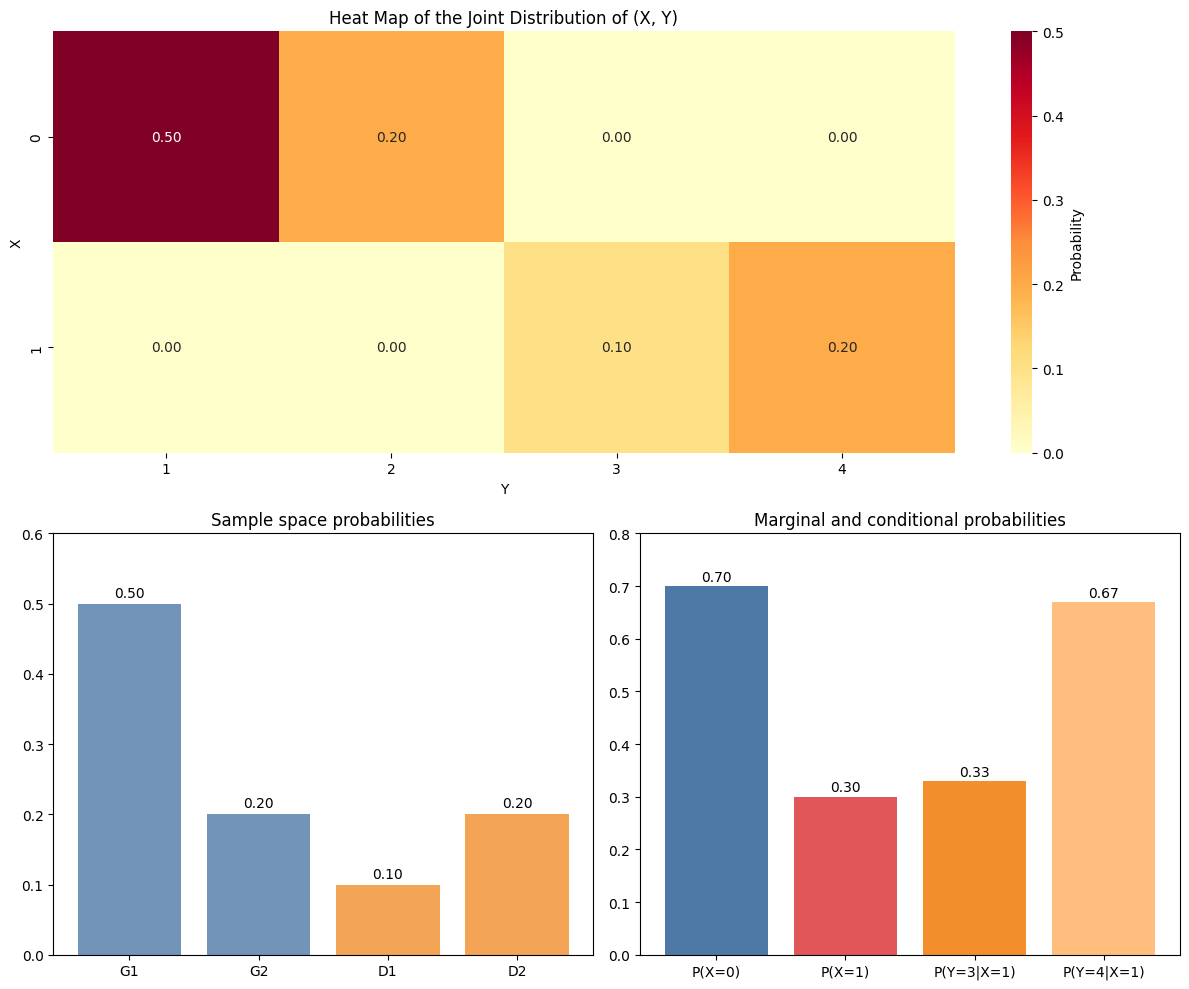

--- Question 12: Shannon Entropy ---
Marginal Entropy H(X): 0.8813 bits
Marginal Entropy H(Y): 1.7610 bits
Joint Entropy H(X, Y): 1.7610 bits
Conditional Entropy H(Y|X): 0.8797 bits


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Data Setup
outcomes = ['G1', 'G2', 'D1', 'D2']
p_y = np.array([0.50, 0.20, 0.10, 0.20])
p_x = np.array([0.70, 0.30])

# Joint Probability Matrix for Heatmap (X rows, Y columns)
joint_matrix = np.array([
    [0.50, 0.20, 0.00, 0.00], # X=0
    [0.00, 0.00, 0.10, 0.20]  # X=1
])

# 11. Visualization (Matching Sir's Sample Style)
fig = plt.figure(figsize=(12, 10))

# Subplot 1: Heatmap
plt.subplot(2, 1, 1)
sns.heatmap(joint_matrix, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=[1, 2, 3, 4], yticklabels=[0, 1], cbar_kws={'label': 'Probability'})
plt.title('Heat Map of the Joint Distribution of (X, Y)')
plt.xlabel('Y')
plt.ylabel('X')

# Subplot 2: Sample Space Probabilities
plt.subplot(2, 2, 3)
plt.bar(outcomes, p_y, color=['#4E79A7', '#4E79A7', '#F28E2B', '#F28E2B'], alpha=0.8)
for i, v in enumerate(p_y):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.title('Sample space probabilities')
plt.ylim(0, 0.6)

# Subplot 3: Marginal/Conditional Probabilities
plt.subplot(2, 2, 4)
# Showing Marginal X and Conditional Y|X=1
compare_probs = [0.70, 0.30, 0.33, 0.67]
compare_labels = ['P(X=0)', 'P(X=1)', 'P(Y=3|X=1)', 'P(Y=4|X=1)']
plt.bar(compare_labels, compare_probs, color=['#4E79A7', '#E15759', '#F28E2B', '#FFBE7D'])
for i, v in enumerate(compare_probs):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.title('Marginal and conditional probabilities')
plt.ylim(0, 0.8)

plt.tight_layout()
plt.show()

# 12. Shannon Entropy Calculation
def entropy(p):
    return -np.sum(p * np.log2(p))

h_x = entropy(p_x)
h_y = entropy(p_y)

print(f"--- Question 12: Shannon Entropy ---")
print(f"Marginal Entropy H(X): {h_x:.4f} bits")
print(f"Marginal Entropy H(Y): {h_y:.4f} bits")
print(f"Joint Entropy H(X, Y): {h_y:.4f} bits")
print(f"Conditional Entropy H(Y|X): {h_y - h_x:.4f} bits")

1.Probability Space $(\Omega, \mathcal{F}, P)$:

    Sample Space: $\Omega = \{G_1, G_2, D_1, D_2\}$$\sigma$-algebra: $\mathcal{F} = \mathcal{P}(\Omega)$ (the power set, containing all 16 possible subsets).
    Probability Measure: $P(G_1)=0.5, P(G_2)=0.2, P(D_1)=0.1, P(D_2)=0.2$.
2.$\sigma$-algebra generated by $X$:$

X$ only distinguishes between "Good" ($G_1, G_2$) and "Defective" ($D_1, D_2$).$$\sigma(X) = \{\emptyset, \Omega, \{G_1, G_2\}, \{D_1, D_2\}\}$$

3.$\sigma$-algebra generated by $Y$:$Y$ gives a unique value for every outcome in $\Omega$. Therefore, it generates the full power set.$$\sigma(Y) = \mathcal{P}(\Omega)$$

4.Why $\sigma(X) \subseteq \sigma(Y)$:Every set in $\sigma(X)$ is also in $\sigma(Y)$, but not vice versa. $Y$ contains more information because if you know the value of $Y$, you can perfectly determine the value of $X$. However, if you only know $X$, you cannot tell which machine produced the item.

9.Interpretation of Conditioning:

  Conditioning on $Y$: Since $Y$ is the "finest" partition, conditioning on $Y$ removes all uncertainty. For example, $P(X=1 \mid Y=3) = 1$.
    
  Conditioning on $X$: This leaves uncertainty about the machine. For example, if we know the item is defective ($X=1$), there is still a probability that it came from Machine 1 or Machine 2.
    
10.Information Availability:

  In $\sigma(Y)$ but not $\sigma(X)$: Information about the Machine ($1$ vs $2$).

  In $\sigma(X)$ but not $\sigma(Y)$: None. Since $X$ is a function of $Y$, all information in $\sigma(X)$ is already contained within $\sigma(Y)$. This is a "coarser" vs "finer" relationship.

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

## Sample Answer

Here is a full sample answer in the same style.

1. The probability space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

$$
\mathfrak F=\mathfrak P(\Omega),
$$

and the probability measure $P$ is defined by

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Since

$$
0.50+0.20+0.10+0.20=1,
$$

this is a valid probability measure.

2. The random variable $X$ records only whether the item is good or defective:

$$
X(G_1)=0,\qquad X(G_2)=0,\qquad X(D_1)=1,\qquad X(D_2)=1.
$$

Thus the inverse images of the values of $X$ are

$$
X^{-1}({0})=\{G_1,G_2\},
$$

and

$$
X^{-1}({1})=\{D_1,D_2\}.
$$

Hence the $\sigma$-algebra generated by $X$ is

$$
\sigma(X)=\left\{\varnothing,\Omega,\{G_1,G_2\},\{D_1,D_2\}\right\}.
$$

3. The random variable $Y$ records both quality and machine:

$$
Y(G_1)=1,\qquad Y(G_2)=2,\qquad Y(D_1)=3,\qquad Y(D_2)=4.
$$

Since each outcome is assigned a distinct value, $Y$ distinguishes every point of $\Omega$. Therefore

$$
\sigma(Y)=\mathfrak P(\Omega).
$$

Explicitly,

$$
\sigma(Y)=\left\{\varnothing,\{G_1\},\{G_2\}\,\{D_1\},\{D_2\},\{G_1,G_2\},\{G_1,D_1\},\ldots,\Omega\right\}.
$$

4. Since every set in $\sigma(X)$ is also a subset of $\Omega$, and $\sigma(Y)=\mathfrak P(\Omega)$, we have

$$
\sigma(X)\subseteq \sigma(Y).
$$

Thus $Y$ contains more information than $X$. The variable $X$ tells us only whether the item is good or defective, while $Y$ tells us both the quality and the machine that produced it.

5. The marginal distribution of $X$ is

$$
P(X=0)=P(\{G_1,G_2\})=0.50+0.20=0.70,
$$

and

$$
P(X=1)=P(\{D_1,D_2\})=0.10+0.20=0.30.
$$

So the PMF of $X$ is

$$
P(X=0)=0.70,\qquad P(X=1)=0.30.
$$

6. The marginal distribution of $Y$ is

$$
P(Y=1)=P(\{G_1\})=0.50,
$$

$$
P(Y=2)=P(\{G_2\})=0.20,
$$

$$
P(Y=3)=P(\{D_1\})=0.10,
$$

$$
P(Y=4)=P(\{D_2\})=0.20.
$$

7. The joint probabilities are

$$
P(X=0,Y=1)=P(\{G_1\})=0.50,
$$

$$
P(X=0,Y=2)=P(\{G_2\})=0.20,
$$

$$
P(X=1,Y=3)=P(\{D_1\})=0.10,
$$

$$
P(X=1,Y=4)=P(\{D_2\})=0.20.
$$

All other joint probabilities are zero, since the values of $X$ and $Y$ are tied to specific outcomes.

8. The conditional probabilities are

$$
P(X=1\mid Y=3)=1,
$$

because $Y=3$ means the outcome is certainly $D_1$, which is defective.

Similarly,

$$
P(X=1\mid Y=4)=1.
$$

Now

$$
P(Y=3\mid X=1)=\frac{P(Y=3,X=1)}{P(X=1)}
=\frac{0.10}{0.30}
=\frac{1}{3},
$$

and

$$
P(Y=4\mid X=1)=\frac{P(Y=4,X=1)}{P(X=1)}
=\frac{0.20}{0.30}
=\frac{2}{3}.
$$

9. Conditioning on $Y$ gives more precise information than conditioning on $X$. If we know $Y=3$, then we know with certainty that the item is defective, so

$$
P(X=1\mid Y=3)=1.
$$

But if we know only that $X=1$, we know the item is defective but we do not know which machine produced it. Then there is still uncertainty:

$$
P(Y=3\mid X=1)=\frac{1}{3},\qquad P(Y=4\mid X=1)=\frac{2}{3}.
$$

10. The $\sigma$-algebra $\sigma(X)$ contains only the information about quality class:

* whether the item is good,
* or whether it is defective.

It does not distinguish between Machine 1 and Machine 2.

By contrast, $\sigma(Y)$ contains full information about the outcome. It tells us both whether the item is good or defective and which machine produced it. Thus $\sigma(Y)$ is strictly finer than $\sigma(X)$.

A concise conclusion is:

> The two random variables are defined on the same sample space, but they generate different $\sigma$-algebras. Since
> $$
> \sigma(X)\subseteq \sigma(Y),
> $$
> the variable $Y$ carries more information than $X$. This is reflected in the conditional probabilities: conditioning on $Y$ can remove uncertainty that remains when conditioning only on $X$.


### Python Visualization

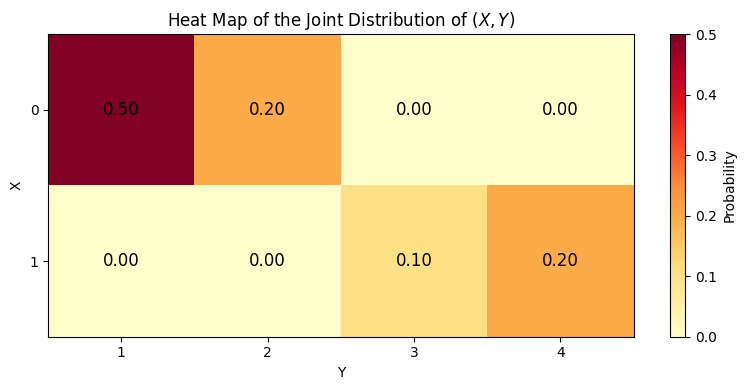

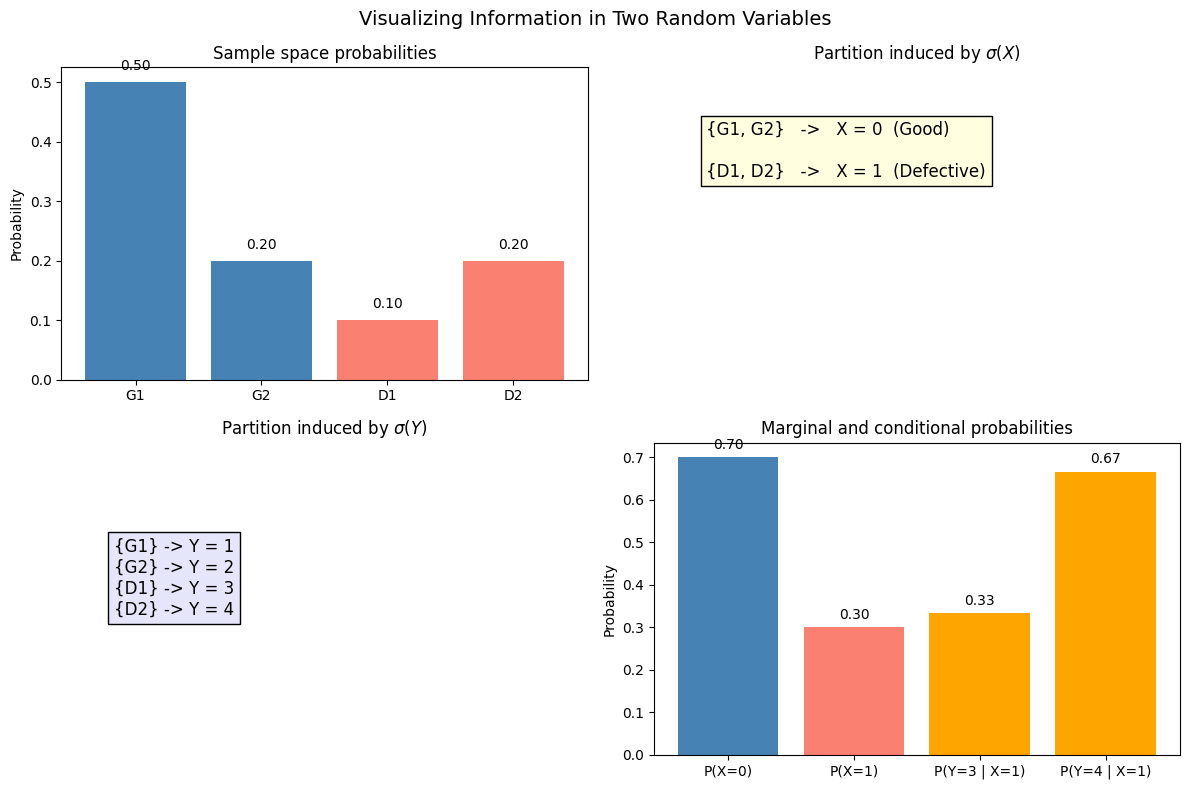

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Sample space probabilities
omega = ["G1", "G2", "D1", "D2"]
p = np.array([0.50, 0.20, 0.10, 0.20])

# Random variables
X = {"G1": 0, "G2": 0, "D1": 1, "D2": 1}
Y = {"G1": 1, "G2": 2, "D1": 3, "D2": 4}

# Marginals
px = {
    0: p[0] + p[1],
    1: p[2] + p[3]
}

py = {
    1: p[0],
    2: p[1],
    3: p[2],
    4: p[3]
}



# Joint distribution table for (X,Y)
# Rows correspond to X = 0, 1
# Columns correspond to Y = 1, 2, 3, 4

joint = np.array([
    [0.50, 0.20, 0.00, 0.00],  # X = 0
    [0.00, 0.00, 0.10, 0.20]   # X = 1
])

fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(joint, cmap="YlOrRd", aspect="auto")

# Axis labels
ax.set_xticks(range(4))
ax.set_xticklabels([1, 2, 3, 4])
ax.set_yticks(range(2))
ax.set_yticklabels([0, 1])

ax.set_xlabel("Y")
ax.set_ylabel("X")
ax.set_title("Heat Map of the Joint Distribution of $(X,Y)$")

# Add probability values inside cells
for i in range(joint.shape[0]):
    for j in range(joint.shape[1]):
        ax.text(j, i, f"{joint[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=12)

# Color bar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")

plt.tight_layout()
plt.show()

# Conditionals
p_y3_given_x1 = p[2] / (p[2] + p[3])
p_y4_given_x1 = p[3] / (p[2] + p[3])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Visualizing Information in Two Random Variables", fontsize=14)

# 1. Sample space probabilities
axes[0, 0].bar(omega, p, color=["steelblue", "steelblue", "salmon", "salmon"])
axes[0, 0].set_title("Sample space probabilities")
axes[0, 0].set_ylabel("Probability")
for i, val in enumerate(p):
    axes[0, 0].text(i, val + 0.02, f"{val:.2f}", ha="center")

# 2. Partition induced by X
axes[0, 1].axis("off")
axes[0, 1].set_title(r"Partition induced by $\sigma(X)$")
axes[0, 1].text(
    0.1, 0.65,
    "{G1, G2}   ->   X = 0  (Good)\n\n{D1, D2}   ->   X = 1  (Defective)",
    fontsize=12,
    bbox=dict(facecolor="lightyellow", edgecolor="black")
)

# 3. Partition induced by Y
axes[1, 0].axis("off")
axes[1, 0].set_title(r"Partition induced by $\sigma(Y)$")
axes[1, 0].text(
    0.1, 0.45,
    "{G1} -> Y = 1\n{G2} -> Y = 2\n{D1} -> Y = 3\n{D2} -> Y = 4",
    fontsize=12,
    bbox=dict(facecolor="lavender", edgecolor="black")
)

# 4. Marginal of X and conditional of Y given X=1
x_labels = ["P(X=0)", "P(X=1)", "P(Y=3 | X=1)", "P(Y=4 | X=1)"]
x_vals = [px[0], px[1], p_y3_given_x1, p_y4_given_x1]
axes[1, 1].bar(x_labels, x_vals, color=["steelblue", "salmon", "orange", "orange"])
axes[1, 1].set_title("Marginal and conditional probabilities")
axes[1, 1].set_ylabel("Probability")
for i, val in enumerate(x_vals):
    axes[1, 1].text(i, val + 0.02, f"{val:.2f}", ha="center")

plt.tight_layout()
plt.show()

### Entropies

Using natural logarithms, the Shannon entropy is

$$
H(Z)=-\sum_z P(z)\ln P(z).
$$

so

$$
H(X)=-(0.70\ln 0.70+0.30\ln 0.30),
$$


$$
H(Y)=-(0.50\ln 0.50+0.20\ln 0.20+0.10\ln 0.10+0.20\ln 0.20).
$$

Thus
$$
H(X)\approx 0.61086,
$$

and

$$
H(Y)\approx 1.22061.
$$

For the joint entropy,

$$
H(X,Y)= -\sum_{x,y} P(x,y)\ln P(x,y),
$$

so only the nonzero terms contribute:

$$
H(X,Y)=-(0.50\ln 0.50+0.20\ln 0.20+0.10\ln 0.10+0.20\ln 0.20).
$$

Therefore

$$
H(X,Y)\approx 1.22061.
$$

Since each value of $Y$ determines $X$ exactly,

$$
H(X\mid Y)=0.
$$

Also,

$$
H(Y\mid X)=H(X,Y)-H(X),
$$

so

$$
H(Y\mid X)\approx 1.22061-0.61086=0.60975.
$$

So in natural logarithm form:

$$
H(X)\approx 0.61086
$$

$$
H(Y)\approx 1.22061
$$

$$
H(X,Y)\approx 1.22061
$$

$$
H(X\mid Y)=0
$$

$$
H(Y\mid X)\approx 0.60975
$$

---

A useful interpretation is:

$H(X)$ measures uncertainty about whether an item is good or defective,

$H(Y)$ measures uncertainty about the full category,

$H(X\mid Y)=0$ because knowing $Y$ tells us $X$ exactly,

$H(Y\mid X)>0$ because knowing only $X$ does not tell us which machine produced the item.

So this entropy calculation gives another precise way to say that $Y$ contains more information than $X$.

# Q10) Information Available in Continuous Random Varaibles

1.Probability Space $(\Omega, \mathcal{F}, P)$

  Sample Space ($\Omega$): $\mathbb{R}^2$, representing the joint state of temperature ($t$) and pressure ($p$).

  sigma$-algebra ($\mathcal{F}$): The Borel $\sigma$-algebra $\mathcal{B}(\mathbb{R}^2)$.

  Probability Measure ($P$): Defined by the joint density function:$$

   $$f_{T,P}(t,p) = \frac{1}{4\pi} \exp\left(-\frac{t^2}{2} - \frac{p^2}{8}\right)$$
   
2.$\sigma$-algebra generated by $X$, $\sigma(X)$

  $X$ records only temperature. It cannot distinguish between points with different pressures. Thus, its events are vertical strips:
  
  $$\sigma(X) = \{ B \times \mathbb{R} : B \in \mathcal{B}(\mathbb{R}) \}$$
  
3.$\sigma$-algebra generated by $Y$, $\sigma(Y)$
  
$Y$ records the full state $(t, p)$, therefore it generates the full Borel $\sigma$-algebra of the plane:$$\sigma(Y) = \mathcal{B}(\mathbb{R}^2)$$

4.Inclusion Relationship

$\sigma(X) \subseteq \sigma(Y)$. This shows that $Y$ contains more information than $X$. $X$ is a "coarser" random variable because it "blurs" the pressure dimension.

5.Marginal Density of $X$:$X \sim N(0, 1) \implies f_X(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$

6.Marginal Density of $Y$:Since $T$ and $P$ are independent, the marginal density of $Y$ is the joint density $f_{T,P}(t,p)$.

7.Specific Probabilities:

$P(X \leq 0) = 0.5$$P(X > 1) = 1 - \Phi(1) \approx 0.1587$$P(Y \in [-1, 1] \times [-2, 2]) = P(-1 \leq T \leq 1) \cdot P(-2 \leq P \leq 2)$

8.Conditional Distribution of $X$ given $Y=(t,p)$:Since $Y$ determines $X$ exactly ($X=t$), the distribution is a Dirac delta $\delta(x-t)$.

9.Conditional Distribution of $Y$ given $X=t$:Due to independence, the distribution of $P$ is unchanged. $Y|X=t \sim \{t\} \times N(0, 4)$.

10.Interpretation:Conditioning on $X$ provides "partial information" (fixing one coordinate), while conditioning on $Y$ provides "total information" (fixing the exact point in 2D space).

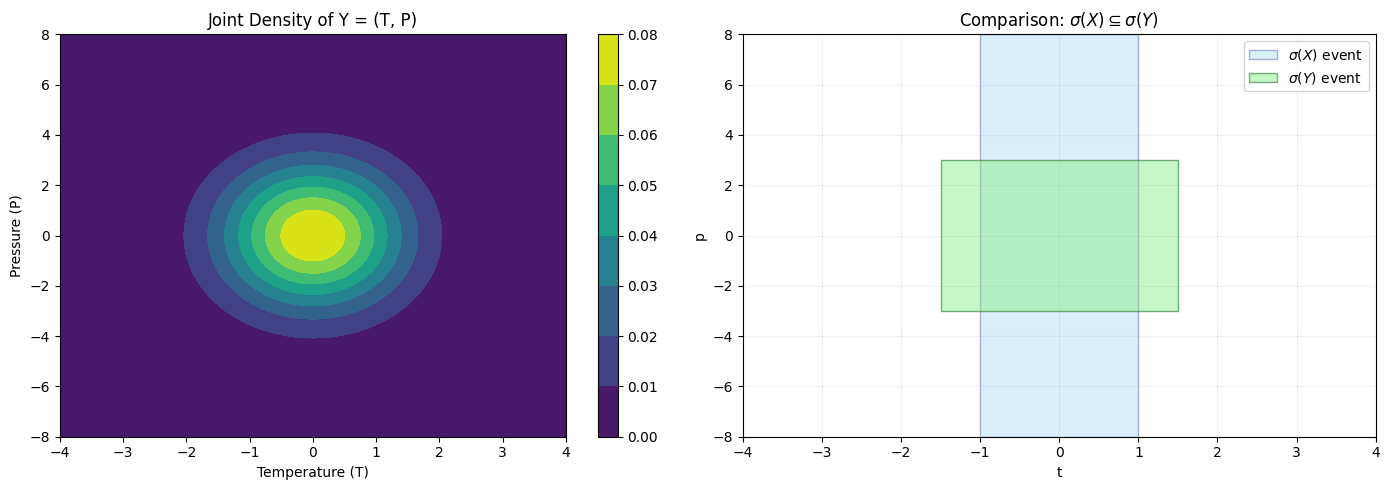

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import multivariate_normal

# Parameters
xlim, ylim = (-4, 4), (-8, 8)
t = np.linspace(xlim[0], xlim[1], 100)
p = np.linspace(ylim[0], ylim[1], 100)
T, P = np.meshgrid(t, p)

# 1. Joint Density Heatmap
rv = multivariate_normal([0, 0], [[1, 0], [0, 4]])
Z = rv.pdf(np.dstack((T, P)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Joint Density
ax0 = axes[0]
contour = ax0.contourf(T, P, Z, cmap='viridis')
plt.colorbar(contour, ax=ax0)
ax0.set_title("Joint Density of Y = (T, P)")
ax0.set_xlabel("Temperature (T)")
ax0.set_ylabel("Pressure (P)")

# Plot B: sigma-algebra Comparison (Sir's Style)
ax1 = axes[1]
ax1.set_title(r"Comparison: $\sigma(X) \subseteq \sigma(Y)$")
ax1.set_xlim(xlim); ax1.set_ylim(ylim)
# sigma(X) sees only vertical strips
strip = Rectangle((-1, ylim[0]), 2, ylim[1]-ylim[0], facecolor="skyblue", edgecolor="navy", alpha=0.3, label=r"$\sigma(X)$ event")
# sigma(Y) sees specific 2D regions
rect = Rectangle((-1.5, -3), 3, 6, facecolor="lightgreen", edgecolor="darkgreen", alpha=0.5, label=r"$\sigma(Y)$ event")
ax1.add_patch(strip); ax1.add_patch(rect)
ax1.legend()
ax1.set_xlabel("t"); ax1.set_ylabel("p")
ax1.grid(alpha=0.2)

plt.tight_layout()
plt.show()

13.Differential Entropy $h(X)$:

$$h(X) = \frac{1}{2}\ln(2\pi e \sigma^2) = \frac{1}{2}\ln(2\pi e) \approx 1.4189 \text{ nats}$$

14.Differential Entropy $h(Y)$:

  Since $T$ and $P$ are independent: h(Y) = h(T) + h(P)
  
  $h(Y) = 1.4189 + \frac{1}{2}\ln(2\pi e \cdot 4) \approx 3.5123 \text{ nats}$$
  
15.Conditional Differential Entropy $h(Y|X)$:

$h(Y|X) = h(P) \approx 2.0933$ nats.

Physical Interpretation:
  This is the residual uncertainty in the sensor state given that the temperature is already known.
  
16.Discussion of $h(X|Y)$:

In this continuous model, $h(X|Y) = -\infty$. While in the discrete case $H(X|Y)=0$ when $Y$ determines $X$, the continuous case results in negative infinity because the variance of $X$ given $Y$ is zero, and $\ln(0) \to -\infty$.

In [3]:
import math

h_x = 0.5 * math.log(2 * math.pi * math.e * 1)
h_p = 0.5 * math.log(2 * math.pi * math.e * 4)
h_y = h_x + h_p

print(f"13. h(X): {h_x:.4f} nats")
print(f"14. h(Y): {h_y:.4f} nats")
print(f"15. h(Y|X): {h_p:.4f} nats")
print(f"16. h(X|Y): -inf")

13. h(X): 1.4189 nats
14. h(Y): 3.5310 nats
15. h(Y|X): 2.1121 nats
16. h(X|Y): -inf


A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


## Sample Answer

1. The probability space is

    $$
    \Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
    $$

    where $\mathfrak B(\mathbb R^2)$ is the Borel $\sigma$-algebra on $\mathbb R^2$.

    A point $\omega\in\Omega$ has the form

    $$
    \omega=(t,p),
    $$

    where $t$ is the standardized temperature deviation and $p$ is the standardized pressure deviation.

    The probability measure $P$ is defined by the joint density

    $$
    f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
    $$

    Thus for any Borel set $A\subseteq\mathbb R^2$,

    $$
    P(A)=\iint_A f_{T,P}(t,p)dt dp.
    $$

    Since $T\sim N(0,1)$ and $P\sim N(0,4)$ are independent, this is a valid probability measure.

---

2. The random variable $X$ is defined by

    $$
    X(t,p)=t.
    $$

    Thus $X$ records only the temperature deviation.

    The $\sigma$-algebra generated by $X$ is

    $$
    \sigma(X)=\{X^{-1}(B): B\in\mathfrak B(\mathbb R)\}.
    $$

    Since

    $$
    X^{-1}(B)=\{(t,p)\in\mathbb R^2:t\in B\}=B\times \mathbb R,
    $$

    we obtain

    $$
    \sigma(X)=\{B\times\mathbb R: B\in\mathfrak B(\mathbb R)\}.
    $$

    So $\sigma(X)$ consists exactly of all sets that depend only on the temperature coordinate.

---

3. The random variable $Y$ is defined by

    $$
    Y(t,p)=(t,p).
    $$

    Thus $Y$ records both temperature and pressure.

    Since $Y$ is the identity map on $\mathbb R^2$, its generated $\sigma$-algebra is

    $$
    \sigma(Y)=\mathfrak B(\mathbb R^2).
    $$

    Indeed, for every Borel set $A\subseteq\mathbb R^2$,

    $$
    Y^{-1}(A)=A.
    $$

    Hence

    $$
    \sigma(Y)=\mathfrak B(\mathbb R^2).
    $$

---

4. Since every set of the form $B\times\mathbb R$ is a Borel subset of $\mathbb R^2$, we have

    $$
    \sigma(X)\subseteq \sigma(Y).
    $$

    The inclusion is strict, because sets such as

    $$
    [-1,1]\times[-2,2]
    $$

    belong to $\sigma(Y)$ but not to $\sigma(X)$, since they depend on both coordinates.

    Thus $Y$ contains more information than $X$: knowing $X$ tells us only the temperature deviation, while knowing $Y$ tells us both temperature and pressure deviations.

---

5. The marginal density of $X$ is obtained by integrating out $p$:

    $$
    f_X(x)=\int_{-\infty}^{\infty} f_{T,P}(x,p)dp.
    $$

    So

    $$
    f_X(x)=\int_{-\infty}^{\infty}\frac{1}{4\pi}\exp\left(-\frac{x^2}{2}-\frac{p^2}{8}\right)dp.
    $$

    Since

    $$
    \int_{-\infty}^{\infty}\frac{1}{\sqrt{8\pi}}\exp\left(-\frac{p^2}{8}\right)dp=1,
    $$

    this simplifies to

    $$
    f_X(x)=\frac{1}{\sqrt{2\pi}}\exp\left(-\frac{x^2}{2}\right).
    $$

    Thus

    $$
    X\sim N(0,1).
    $$

---

6. The marginal density of $Y$ is simply its joint density, since $Y=(T,P)$:

    $$
    f_Y(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right).
    $$

    Thus $Y$ is a bivariate normal random vector with independent components.

---

7. First,

    $$
    P(X\leq 0)=P(T\leq 0)=\frac{1}{2},
    $$

    by symmetry of the standard normal distribution.

    Next,

    $$
    P(X>1)=P(T>1)=1-\Phi(1),
    $$

    where $\Phi$ is the standard normal distribution function. Numerically,

    $$
    P(X>1)\approx 0.1587.
    $$

    Now

    $$
    P\bigl(Y\in (-\infty,0]\times\mathbb R\bigr)=P(T\leq 0)=\frac{1}{2}.
    $$

    Finally,

    $$
    P\bigl(Y\in[-1,1]\times[-2,2]\bigr)=P(-1\leq T\leq 1,-2\leq P\leq 2).
    $$

    Since $T$ and $P$ are independent,

    $$
    P\bigl(Y\in[-1,1]\times[-2,2]\bigr)=P(-1\leq T\leq 1)\,P(-2\leq P\leq 2).
    $$

    Now $T\sim N(0,1)$, so

    $$
    P(-1\leq T\leq 1)=2\Phi(1)-1.
    $$

    Also $P\sim N(0,4)$, so $P/2\sim N(0,1)$, hence

    $$
    P(-2\leq P\leq 2)=P(-1\leq P/2\leq 1)=2\Phi(1)-1.
    $$

    Therefore

    $$
    P\bigl(Y\in[-1,1]\times[-2,2]\bigr)=\bigl(2\Phi(1)-1\bigr)^2.
    $$

    Numerically,

    $$
    2\Phi(1)-1\approx 0.6827,
    $$

    so

    $$
    P\bigl(Y\in[-1,1]\times[-2,2]\bigr)\approx 0.466.
    $$

---

8. Since $Y=(T,P)$ completely determines $T$, the conditional distribution of $X$ given $Y=(t,p)$ is degenerate at $t$:

    $$
    P(X=t\mid Y=(t,p))=1.
    $$

    Equivalently, the conditional law of $X$ given $Y=(t,p)$ is

    $$
    \delta_t,
    $$

    the Dirac mass at $t$.

    This means that once both temperature and pressure are known, the temperature is known exactly.

---

9. The conditional distribution of $Y$ given $X=t$ is the distribution of the random vector $(t, P)$ where $P \sim N(0,4)$. Thus, we have:
   $$Y \mid X=t \sim (t, P).$$
   Since $T$ and $P$ are independent, the conditional probability measure $P_{Y|X=t}$ is the product measure $\delta_t \otimes \mathscr{N}(0,4)$.
   
   The conditional density $f_{Y|X}((u, v) \mid t)$ is the Radon-Nikodym derivative of this measure with respect to the Lebesgue measure (formally involving the Dirac delta distribution), expressed as:
   $$f_{Y|X}\bigl((u,v)\mid t\bigr) = \delta_t(u) \cdot \frac{1}{\sqrt{8\pi}} \exp\left(-\frac{v^2}{8}\right).$$
   
   **Informally:** Given $X=t$, the temperature component is fixed at $t$ (represented by the Dirac mass $\delta_t$), while the pressure component remains normally distributed with its original variance.



---

10. Conditioning on $X$ means that we know only the temperature deviation. There is still uncertainty about the pressure deviation.

    Conditioning on $Y$ means that we know both temperature and pressure. Thus conditioning on $Y$ provides strictly more information.

    In particular:

    * given $X=t$, the pressure is still random;
    * given $Y=(t,p)$, both coordinates are known exactly.

---

11. Define the projection map

    $$
    \pi_1:\mathbb R^2\to\mathbb R, \qquad \pi_1(t,p)=t.
    $$

    Then

    $$
    X=\pi_1\circ Y.
    $$

    Indeed,

    $$
    (\pi_1\circ Y)(t,p)=\pi_1(t,p)=t=X(t,p).
    $$

    Since $\pi_1$ is Borel measurable and $X$ is a measurable function of $Y$, it follows that

    $$
    \sigma(X)\subseteq \sigma(Y).
    $$

    This gives a direct measurable explanation for why $Y$ is more informative than $X$.

---

12. A good Python visualization would include:

* a contour plot or heat map of the joint density
  $$
  f_Y(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right).
  $$

* a plot of the marginal density
  $$
  f_X(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2}.
  $$

* vertical strips such as
  $$
  B\times\mathbb R
  $$
  to illustrate events in $\sigma(X)$;

* rectangles such as
  $$
  [-1,1]\times[-2,2]
  $$
  to illustrate events in $\sigma(Y)$.

The visual message is that $\sigma(X)$ sees only vertical strips, whereas $\sigma(Y)$ sees all Borel subsets of the plane.

---

13. Since $X\sim N(0,1)$, its differential entropy is

    $$
    h(X)=\frac{1}{2}\ln(2\pi e).
    $$

    Numerically,

    $$
    h(X)\approx 1.4189.
    $$

---

14. Since $Y=(T,P)$ has independent normal components with variances $1$ and $4$, its differential entropy is

    $$
    h(Y)=h(T)+h(P).
    $$

    Now

    $$
    h(T)=\frac{1}{2}\ln(2\pi e),
    $$

    and

    $$
    h(P)=\frac{1}{2}\ln(2\pi e\cdot 4).
    $$

    Therefore

    $$
    h(Y)=\frac{1}{2}\ln(2\pi e)+\frac{1}{2}\ln(8\pi e).
    $$

    Equivalently,

    $$
    h(Y)=\frac{1}{2}\ln\bigl((2\pi e)^2\cdot 4\bigr)
    =\ln(2\pi e)+\ln 2.
    $$

    Numerically,

    $$
    h(Y)\approx 3.5310.
    $$

---

15. Since $T$ and $P$ are independent and $Y=(T,P)$, the uncertainty remaining in $Y$ after $X=T$ is exactly the uncertainty in $P$.

    Thus

    $$
    h(Y|X)=h(P)=\frac{1}{2}\ln(2\pi e\cdot 4).
    $$

    So

    $$
    h(Y|X)=\frac{1}{2}\ln(8\pi e).
    $$

    Numerically,

    $$
    h(Y|X)\approx 2.1121.
    $$

    Physically, once the temperature deviation is known, the only remaining uncertainty is the pressure deviation.

---

16. Since $X$ is a deterministic function of $Y$, one might expect that

    $$
    h(X|Y)=0.
    $$

    However, for differential entropy this is not the correct conclusion. In the continuous setting, the conditional law of $X$ given $Y$ is degenerate, so the conditional differential entropy is not an ordinary finite quantity. In fact, it is best understood as formally tending to

    $$
    -\infty.
    $$

    This is one of the major differences between discrete entropy and differential entropy.

    In the discrete case, if $X$ is determined by $Y$, then

    $$
    H(X|Y)=0.
    $$

    In the continuous case, exact deterministic dependence corresponds to a singular conditional distribution, and differential entropy behaves differently.

    Thus this example shows:

    * $\sigma(X)\subseteq \sigma(Y)$,
    * $Y$ contains more information than $X$,
    * $h(Y|X)$ is a meaningful positive quantity,
    * but $h(X|Y)$ is not analogous to the discrete case and reflects the subtleties of continuous entropy.

---

**Conclusion:**

> The variables $X$ and $Y$ are defined on the same probability space, but $X$ is a coarser observation while $Y$ is a finer one. This is reflected in the inclusion
> $$
> \sigma(X)\subseteq \sigma(Y),
> $$
> in the fact that $X$ is a measurable function of $Y$, and in the entropy calculations: knowing $X$ leaves uncertainty about $Y$, but knowing $Y$ determines $X$ exactly.


### Python Visulaization

#### The $\sigma$-algebra visualizations

Here is a good Python visualization of the two $\sigma$-algebras in $\mathbb R^2$ for the example

$$
X(t,p)=t, \qquad Y(t,p)=(t,p).
$$

The idea is:

* $\sigma(X)$ consists of sets of the form
  $$
  B\times \mathbb R,
  $$
  so visually these are **vertical strips** in the plane;

* $\sigma(Y)=\mathfrak B(\mathbb R^2)$ consists of all Borel sets in the plane, so visually we can show a general **rectangle**, **disk**, or other 2D region.

This code creates a figure with:

1. a vertical strip representing an event in $\sigma(X)$,
2. a rectangle representing an event in $\sigma(Y)$,
3. an overlay comparison showing that $\sigma(X)$ is coarser than $\sigma(Y)$.




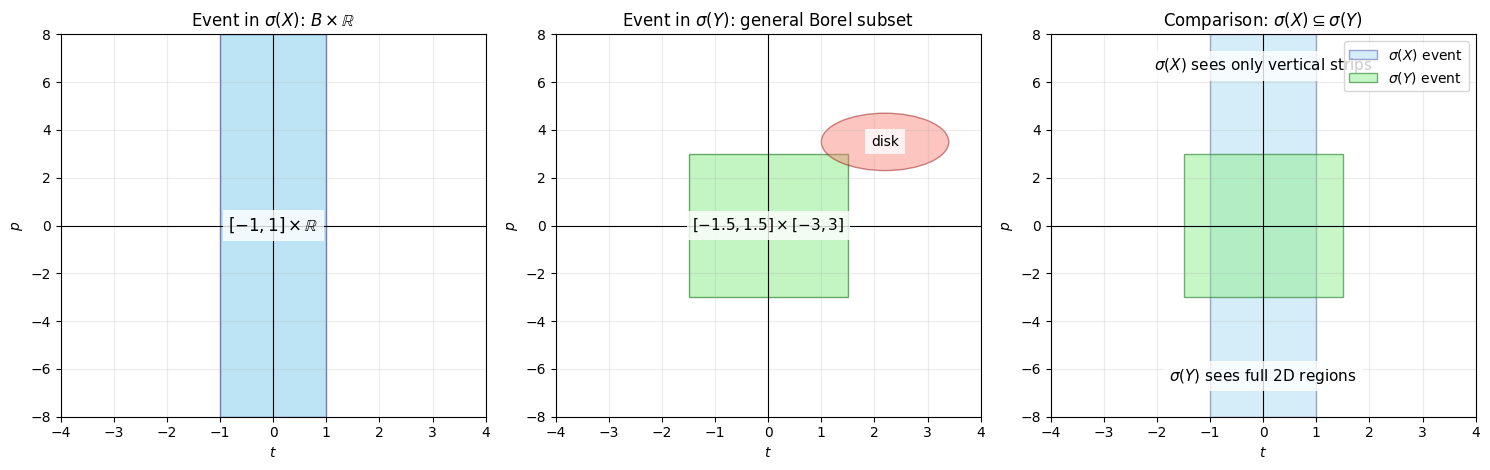

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

xlim = (-4, 4)
ylim = (-8, 8)

# -------------------------
# (1) Event in sigma(X)
# -------------------------
ax = axes[0]
ax.set_title(r"Event in $\sigma(X)$: $B\times\mathbb{R}$")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$p$")

# Example B = [-1,1]
strip = Rectangle((-1, ylim[0]), 2, ylim[1] - ylim[0],
                  facecolor="skyblue", edgecolor="navy", alpha=0.55)
ax.add_patch(strip)

ax.text(0, 0, r"$[-1,1]\times \mathbb{R}$",
        ha="center", va="center", fontsize=12,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))

ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.grid(alpha=0.25)

# -------------------------
# (2) Event in sigma(Y)
# -------------------------
ax = axes[1]
ax.set_title(r"Event in $\sigma(Y)$: general Borel subset")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$p$")

# Example rectangle in sigma(Y)
rect = Rectangle((-1.5, -3), 3, 6,
                 facecolor="lightgreen", edgecolor="darkgreen", alpha=0.55)
ax.add_patch(rect)

# Also add a disk to emphasize generality
disk = Circle((2.2, 3.5), 1.2,
              facecolor="salmon", edgecolor="darkred", alpha=0.45)
ax.add_patch(disk)

ax.text(0, 0, r"$[-1.5,1.5]\times[-3,3]$",
        ha="center", va="center", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
ax.text(2.2, 3.5, r"disk",
        ha="center", va="center", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))

ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.grid(alpha=0.25)

# -------------------------
# (3) Comparison
# -------------------------
ax = axes[2]
ax.set_title(r"Comparison: $\sigma(X)\subseteq\sigma(Y)$")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$p$")

# Vertical strip for sigma(X)
strip2 = Rectangle((-1, ylim[0]), 2, ylim[1] - ylim[0],
                   facecolor="skyblue", edgecolor="navy", alpha=0.35,
                   label=r"$\sigma(X)$ event")
ax.add_patch(strip2)

# Rectangle for sigma(Y)
rect2 = Rectangle((-1.5, -3), 3, 6,
                  facecolor="lightgreen", edgecolor="darkgreen", alpha=0.5,
                  label=r"$\sigma(Y)$ event")
ax.add_patch(rect2)

ax.text(0, 6.5, r"$\sigma(X)$ sees only vertical strips",
        ha="center", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
ax.text(0, -6.5, r"$\sigma(Y)$ sees full 2D regions",
        ha="center", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))

ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.legend(loc="upper right")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

> In this model, $\sigma(X)$ contains exactly the events that depend only on the temperature coordinate $t$, so they appear as vertical strips $B\times \mathbb R$. By contrast, $\sigma(Y)=\mathfrak B(\mathbb R^2)$ contains all Borel subsets of the plane, such as rectangles, disks, and more complicated regions. Thus $\sigma(X)$ is strictly coarser than $\sigma(Y)$.


#### The distributions

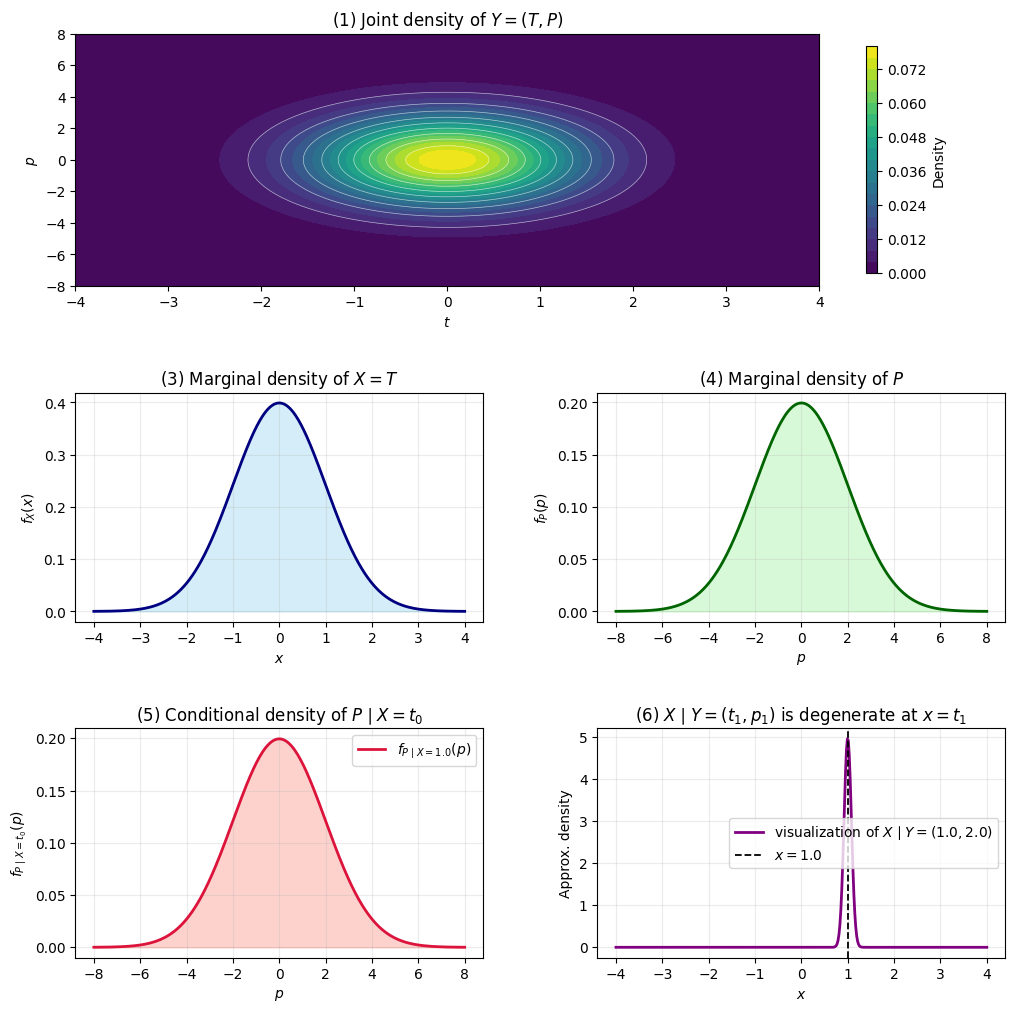

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

# Parameters
mu_T, sigma_T = 0.0, 1.0
mu_P, sigma_P = 0.0, 2.0   # since Var(P)=4

# Grids
t = np.linspace(-4, 4, 400)
p = np.linspace(-8, 8, 400)
T, P = np.meshgrid(t, p)

# Joint density of Y = (T, P)
joint_pdf = (
    norm.pdf(T, loc=mu_T, scale=sigma_T) *
    norm.pdf(P, loc=mu_P, scale=sigma_P)
)

# Marginal density of X = T
fx = norm.pdf(t, loc=mu_T, scale=sigma_T)

# Conditional density of P | X=t0
# Independence implies P | X=t0 ~ N(0,4)
t0 = 1.0
cond_p_given_x = norm.pdf(p, loc=mu_P, scale=sigma_P)

# Conditional distribution of X | Y=(t1,p1):
# Degenerate at t1, approximated here by a narrow Gaussian just for visualization
t1, p1 = 1.0, 2.0
eps = 0.08
cond_x_given_y_vis = norm.pdf(t, loc=t1, scale=eps)

# Figure with subplot layout:
# 1
# 3 4
# 5 6
fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1.1, 1, 1], hspace=0.45, wspace=0.28)

# (1) Joint contour spanning full top row
ax1 = fig.add_subplot(gs[0, :])
cs = ax1.contourf(T, P, joint_pdf, levels=25, cmap="viridis")
ax1.contour(T, P, joint_pdf, levels=10, colors="white", linewidths=0.5, alpha=0.6)
ax1.set_title(r"(1) Joint density of $Y=(T,P)$")
ax1.set_xlabel(r"$t$")
ax1.set_ylabel(r"$p$")
fig.colorbar(cs, ax=ax1, shrink=0.9, label="Density")

# (3) Marginal of X
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(t, fx, color="navy", lw=2)
ax3.fill_between(t, fx, color="skyblue", alpha=0.35)
ax3.set_title(r"(3) Marginal density of $X=T$")
ax3.set_xlabel(r"$x$")
ax3.set_ylabel(r"$f_X(x)$")
ax3.grid(alpha=0.25)

# (4) Marginal of P
ax4 = fig.add_subplot(gs[1, 1])
fp = norm.pdf(p, loc=mu_P, scale=sigma_P)
ax4.plot(p, fp, color="darkgreen", lw=2)
ax4.fill_between(p, fp, color="lightgreen", alpha=0.35)
ax4.set_title(r"(4) Marginal density of $P$")
ax4.set_xlabel(r"$p$")
ax4.set_ylabel(r"$f_P(p)$")
ax4.grid(alpha=0.25)

# (5) Conditional density of P | X=t0
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(p, cond_p_given_x, color="crimson", lw=2,
         label=rf"$f_{{P\mid X={t0}}}(p)$")
ax5.fill_between(p, cond_p_given_x, color="salmon", alpha=0.35)
ax5.set_title(r"(5) Conditional density of $P \mid X=t_0$")
ax5.set_xlabel(r"$p$")
ax5.set_ylabel(r"$f_{P\mid X=t_0}(p)$")
ax5.legend()
ax5.grid(alpha=0.25)

# (6) Visualized conditional of X | Y=(t1,p1)
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(t, cond_x_given_y_vis, color="purple", lw=2,
         label=rf"visualization of $X\mid Y=({t1},{p1})$")
ax6.axvline(t1, color="black", ls="--", lw=1.3, label=rf"$x={t1}$")
ax6.set_title(r"(6) $X\mid Y=(t_1,p_1)$ is degenerate at $x=t_1$")
ax6.set_xlabel(r"$x$")
ax6.set_ylabel("Approx. density")
ax6.legend()
ax6.grid(alpha=0.25)

plt.show()

A small note for subplot (6): in this model, $X \mid Y=(t_1,p_1)$ is not an ordinary density but a point mass at $x=t_1$. The code uses a very narrow Gaussian only to make that visible on a plot.

#Q11) Conditional Expectation

1.Probability Space $(\Omega, \mathcal{F}, P)$

 Sample Space ($\Omega$): $\{\omega_1, \omega_2, \omega_3, \omega_4\}$ (Low-risk Legitimate, Low-risk Fraud, High-risk Legitimate, High-risk Fraud).


 $\sigma$-algebra ($\mathcal{F}$): The power set $\mathcal{P}(\Omega)$, containing 16 events.

 Probabilities: $P(\omega_1)=0.50, P(\omega_2)=0.10, P(\omega_3)=0.20, P(\omega_4)=0.20$.

 2.$\sigma$-algebra generated by $Y$, $\sigma(Y)$$
 Y$ partitions the sample space into low-risk ($Y=0$) and high-risk ($Y=1$).
   $Y=0 \implies \{\omega_1, \omega_2\}$
   $Y=1 \implies \{\omega_3, \omega_4\}$
   
   $$\sigma(Y) = \{ \emptyset, \Omega, \{\omega_1, \omega_2\}, \{\omega_3, \omega_4\} \}$$
   
3.Why $E[X|Y]$ must be $\sigma(Y)$-measurable

By definition, the conditional expectation $E[X|Y]$ is a random variable that uses only the information available in $Y$. Since the bank only observes the "risk class" ($Y$), the estimate of fraud ($X$) must be the same for any outcomes that $Y$ cannot distinguish. Therefore, it must be constant on the sets $\{\omega_1, \omega_2\}$ and $\{\omega_3, \omega_4\}$.

In [4]:
import numpy as np
import pandas as pd

# Data Setup
outcomes = ['w1', 'w2', 'w3', 'w4']
probs = np.array([0.50, 0.10, 0.20, 0.20])
X = np.array([0, 1, 0, 1])  # Fraud Indicator
Y = np.array([0, 0, 1, 1])  # Risk Class

# 4. Explicitly compute E[X | Y]
# P(Y=0) = P(w1) + P(w2)
p_y0 = probs[0] + probs[1]
# E[X | Y=0] = (X(w1)*P(w1) + X(w2)*P(w2)) / P(Y=0)
e_x_y0 = (X[0]*probs[0] + X[1]*probs[1]) / p_y0

# P(Y=1) = P(w3) + P(w4)
p_y1 = probs[2] + probs[3]
# E[X | Y=1] = (X(w3)*P(w3) + X(w4)*P(w4)) / P(Y=1)
e_x_y1 = (X[2]*probs[2] + X[3]*probs[3]) / p_y1

# 6. Overall Expectation E[X]
e_x_total = np.sum(X * probs)

print(f"4. E[X | Y=0] (Low Risk): {e_x_y0:.4f}")
print(f"4. E[X | Y=1] (High Risk): {e_x_y1:.4f}")
print(f"6. Total E[X]: {e_x_total:.4f}")

# 8. Comparison with E[X | G] where G is the full sigma-algebra
# If G = P(Omega), then E[X | G] = X because we know exactly which outcome occurred.
e_x_g = X

# Visualizing the difference
df = pd.DataFrame({
    'Outcome': outcomes,
    'Probability': probs,
    'Actual Fraud (X)': X,
    'Bank Estimate E[X|Y]': [e_x_y0, e_x_y0, e_x_y1, e_x_y1]
})
print("\n--- Summary Table ---")
print(df)

4. E[X | Y=0] (Low Risk): 0.1667
4. E[X | Y=1] (High Risk): 0.5000
6. Total E[X]: 0.3000

--- Summary Table ---
  Outcome  Probability  Actual Fraud (X)  Bank Estimate E[X|Y]
0      w1          0.5                 0              0.166667
1      w2          0.1                 1              0.166667
2      w3          0.2                 0              0.500000
3      w4          0.2                 1              0.500000


7.Practical Interpretation:

$E[X|Y]$ tells the bank the probability of fraud given only the customer's risk profile.

  For a low-risk customer ($Y=0$), the chance of fraud is 16.67%.
  
  For a high-risk customer ($Y=1$), the chance of fraud is 50.00%.
  
  This helps the bank decide which transactions to flag for manual review even when they don't know the actual outcome yet.
  
9.The "Best Estimate" Concept:This example shows that conditional expectation is the "best estimate" because it minimizes the mean squared error based on the information we have. If we only know $Y$, we cannot predict $X$ perfectly (which would be 0 or 1), so we take the weighted average (the expectation) over the groups we can see. As we gain more information (moving from $E[X]$ to $E[X|Y]$ to $E[X|\mathcal{G}]$), our estimate gets closer to the actual value of $X$.

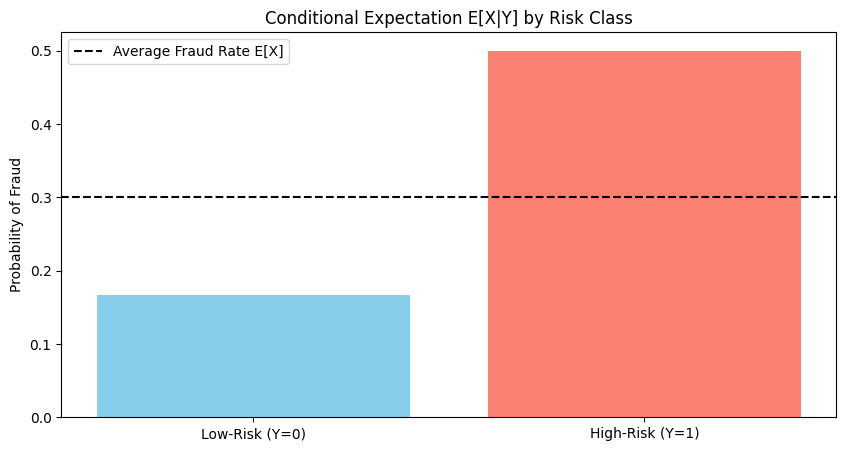

In [5]:
import matplotlib.pyplot as plt

# Visualization of estimates
plt.figure(figsize=(10, 5))
plt.bar(['Low-Risk (Y=0)', 'High-Risk (Y=1)'], [e_x_y0, e_x_y1], color=['skyblue', 'salmon'])
plt.axhline(e_x_total, color='black', linestyle='--', label='Average Fraud Rate E[X]')
plt.ylabel('Probability of Fraud')
plt.title('Conditional Expectation E[X|Y] by Risk Class')
plt.legend()
plt.show()

A bank monitors credit-card transactions for possible fraud.

For each transaction, let the sample space be

$$
\Omega=\{\omega_1,\omega_2,\omega_3,\omega_4\},
$$

where:

* $\omega_1$: low-risk customer, legitimate transaction,
* $\omega_2$: low-risk customer, fraudulent transaction,
* $\omega_3$: high-risk customer, legitimate transaction,
* $\omega_4$: high-risk customer, fraudulent transaction.

Assume the probabilities are

$$
P(\{\omega_1\})=0.50,\qquad
P(\{\omega_2\})=0.10,\qquad
P(\{\omega_3\})=0.20,\qquad
P(\{\omega_4\})=0.20.
$$

Let $X:\Omega\to\mathbb R$ denote the fraud indicator:

$$
X(\omega_1)=0,\qquad
X(\omega_2)=1,\qquad
X(\omega_3)=0,\qquad
X(\omega_4)=1.
$$

Thus $X=1$ means the transaction is fraudulent, and $X=0$ means it is legitimate.

Now suppose the bank does not observe the full outcome $\omega$, but only the customer’s risk class. Define $Y:\Omega\to\mathbb R$ by

$$
Y(\omega_1)=0,\qquad
Y(\omega_2)=0,\qquad
Y(\omega_3)=1,\qquad
Y(\omega_4)=1.
$$

Thus:

* $Y=0$ means “low-risk customer,”
* $Y=1$ means “high-risk customer.”

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

3. Explain why $E[X\mid Y]$ must be $\sigma(Y)$-measurable, and therefore must be constant on the sets ${ \omega_1,\omega_2}$ and ${\omega_3,\omega_4}$.

4. Compute $E[X\mid Y]$ explicitly.

5. Verify the defining property of conditional expectation by checking that for every set $A\in\sigma(Y)$,

$$
\int_A E[X\mid Y]\,dP=\int_A X\,dP.
$$

6. Compute $E[X]$ and compare it with $E[X\mid Y]$.

7. Interpret $E[X\mid Y]$ in practical terms. What does it tell the bank?

8. Let

$$
\mathfrak G=\mathfrak P(\Omega).
$$

Compute $E[X\mid \mathfrak G]$ and compare it with $E[X\mid Y]$.

9. Explain how this example shows that conditional expectation is the “best estimate of $X$ using only the information contained in $Y$.”

## Sample Answer

1. The probability space is

$$
\Omega=\{\omega_1,\omega_2,\omega_3,\omega_4\},
$$

$$
\mathfrak F=\mathfrak P(\Omega),
$$

and the probability measure $P$ is defined by

$$
P(\{\omega_1\})=0.50,\qquad
P(\{\omega_2\})=0.10,\qquad
P(\{\omega_3\})=0.20,\qquad
P(\{\omega_4\})=0.20.
$$

Since

$$
0.50+0.10+0.20+0.20=1,
$$

this is a valid probability measure.

---

2. The random variable $Y$ is defined by

$$
Y(\omega_1)=0,\qquad
Y(\omega_2)=0,\qquad
Y(\omega_3)=1,\qquad
Y(\omega_4)=1.
$$

Thus the inverse images of the values of $Y$ are

$$
Y^{-1}({0})=\{\omega_1,\omega_2\},
$$

and

$$
Y^{-1}({1})=\{\omega_3,\omega_4\}.
$$

Therefore the $\sigma$-algebra generated by $Y$ is

$$
\sigma(Y)=\left\{\varnothing,\Omega,\{\omega_1,\omega_2\},\{\omega_3,\omega_4\}\right\}.
$$

---

3. By definition, $E[X\mid Y]$ must be $\sigma(Y)$-measurable. This means it can depend only on the value of $Y$, not on the full outcome $\omega$.

Since $\sigma(Y)$ can distinguish only the two sets

$$
\{\omega_1,\omega_2\}
\quad \text{and} \quad
\{\omega_3,\omega_4\},
$$

the random variable $E[X\mid Y]$ must be constant on each of these sets.

So we write

$$
E[X\mid Y](\omega)=
\begin{cases}
a, & \omega\in{\omega_1,\omega_2},\\
b, & \omega\in{\omega_3,\omega_4},
\end{cases}
$$

for some constants $a$ and $b$ to be determined.

---

4. To find $a$ and $b$, we use the defining property of conditional expectation.

On the set $\{\omega_1,\omega_2\}$,

$$
\int_{\{\omega_1,\omega_2\}} E[X\mid Y]\,dP\int_{\{\omega_1,\omega_2\}} X,dP.
$$

The left-hand side is

$$
a\cdot P({\omega_1,\omega_2})=a(0.50+0.10)=0.60a.
$$

The right-hand side is

$$
0\cdot 0.50 + 1\cdot 0.10 = 0.10.
$$

So

$$
0.60a=0.10,
$$

hence

$$
a=\frac{0.10}{0.60}=\frac{1}{6}.
$$

On the set $\{\omega_3,\omega_4\}$,

$$
\int_{\{\omega_3,\omega_4\}} E[X\mid Y]\,dP=\int_{\{\omega_3,\omega_4\}} X\,dP.
$$

The left-hand side is

$$
b\cdot P(\{\omega_3,\omega_4\})=b(0.20+0.20)=0.40b.
$$

The right-hand side is

$$
0\cdot 0.20 + 1\cdot 0.20 = 0.20.
$$

So

$$
0.40b=0.20,
$$

hence

$$
b=\frac{0.20}{0.40}=\frac{1}{2}.
$$

Therefore

$$
E[X\mid Y](\omega)=
\begin{cases}
\dfrac{1}{6}, & \omega\in\{\omega_1,\omega_2\},\\
\dfrac{1}{2}, & \omega\in\{\omega_3,\omega_4\}.
\end{cases}
$$

Equivalently, as a function of $Y$,

$$
E[X\mid Y]=
\begin{cases}
\dfrac{1}{6}, & Y=0,\\
\dfrac{1}{2}, & Y=1.
\end{cases}
$$

---

5. We now verify the defining property

$$
\int_A E[X\mid Y],dP=\int_A X\,dP
\qquad \forall A\in\sigma(Y).
$$

The sets in $\sigma(Y)$ are

$$
\varnothing,\qquad \Omega,\qquad \{\omega_1,\omega_2\},\qquad \{\omega_3,\omega_4\}.
$$

For $A=\varnothing$, both integrals are clearly $0$.

For

$$
A=\{\omega_1,\omega_2\},
$$

we already computed

$$
\int_A E[X\mid Y]\,dP = \frac{1}{6}\cdot 0.60 = 0.10,
$$

and

$$
\int_A X\,dP = 0\cdot 0.50 + 1\cdot 0.10 = 0.10.
$$

For

$$
A=\{\omega_3,\omega_4\},
$$

we already computed

$$
\int_A E[X\mid Y]\,dP = \frac{1}{2}\cdot 0.40 = 0.20,
$$

and

$$
\int_A X,dP = 0\cdot 0.20 + 1\cdot 0.20 = 0.20.
$$

For

$$
A=\Omega,
$$

we have

$$
\int_\Omega E[X\mid Y]\,dP=\frac{1}{6}\cdot 0.60 + \frac{1}{2}\cdot 0.40+0.10+0.20+0.30.
$$

Also,

$$
\int_\Omega X\,dP=0\cdot 0.50 + 1\cdot 0.10 + 0\cdot 0.20 + 1\cdot 0.20+0.30.
$$

So the defining property holds for every $A\in\sigma(Y)$.

---

6. The expectation of $X$ is

$$
E[X]=
0\cdot 0.50 + 1\cdot 0.10 + 0\cdot 0.20 + 1\cdot 0.20+0.30.
$$

Thus

$$
E[X]=0.30.
$$

By contrast,

$$
E[X\mid Y]=
\begin{cases}
\dfrac{1}{6}, & Y=0,\\
\dfrac{1}{2}, & Y=1.
\end{cases}
$$

So the unconditional fraud probability is $0.30$, but once the bank knows the risk class, the fraud probability changes:

* for low-risk customers,
  $$
  P(\text{fraud}\mid Y=0)=\frac{1}{6}\approx 0.167,
  $$

* for high-risk customers,
  $$
  P(\text{fraud}\mid Y=1)=\frac{1}{2}=0.50.
  $$

---

7. In practical terms, $E[X\mid Y]$ is the bank's best estimate of the probability of fraud using only the customer's risk class.

Since $X$ is an indicator variable, its conditional expectation is a conditional probability:

$$
E[X\mid Y]=P(X=1\mid Y).
$$

So:

* if the customer is low-risk, the estimated fraud probability is $\frac{1}{6}$;
* if the customer is high-risk, the estimated fraud probability is $\frac{1}{2}$.

This is exactly the kind of quantity a fraud detection system would use for risk scoring.

---

8. Let

$$
\mathfrak G=\mathfrak P(\Omega).
$$

This is the full $\sigma$-algebra, so it contains complete information about the outcome.

Therefore,

$$
E[X\mid \mathfrak G]=X.
$$

Indeed, since $X$ is already $\mathfrak G$-measurable, conditioning on the full information leaves it unchanged.

Thus

$$
E[X\mid \mathfrak G](\omega_1)=0,\qquad
E[X\mid \mathfrak G](\omega_2)=1,\qquad
E[X\mid \mathfrak G](\omega_3)=0,\qquad
E[X\mid \mathfrak G](\omega_4)=1.
$$

Comparing this with

$$
E[X\mid Y](\omega)=
\begin{cases}
\dfrac{1}{6}, & \omega\in\{\omega_1,\omega_2\},\\
\dfrac{1}{2}, & \omega\in\{\omega_3,\omega_4\},
\end{cases}
$$

we see that $E[X\mid Y]$ is a coarser estimate. It averages over all outcomes that the variable $Y$ cannot distinguish.

---

9. This example shows that conditional expectation is the best estimate of $X$ subject to an information restriction.

The true variable $X$ tells us exactly whether the transaction is fraudulent. But if we are only allowed to use the information in $\sigma(Y)$, then we cannot distinguish between:

$$
\omega_1 \text{ and } \omega_2,
\qquad
\omega_3 \text{ and } \omega_4.
$$

So the estimate must be constant on each of those two sets.

The conditional expectation

$$
E[X\mid Y]
$$

is therefore the average value of $X$ within each information class determined by $Y$.

That is why it is interpreted as the best estimate of $X$ using only the information contained in $Y$.

---

**Conclusion**:

> The random variable $X$ records the true fraud outcome, while $Y$ records only the customer's risk class. Since $E[X\mid Y]$ must be $\sigma(Y)$-measurable, it cannot distinguish outcomes that $Y$ does not distinguish. It therefore averages $X$ over the cells of the partition generated by $Y$, yielding the best estimate of fraud probability available under that information constraint.
